In [33]:
# ==========================================
# STEP 1: LOAD & PARSE DATA
# Workflow: Check -> Display -> Change -> Verify
# ==========================================
import pandas as pd
import numpy as np
import re

# 1. CHANGE (Define and apply parser during load)
def parse_messy_numbers(val):
    if pd.isna(val): return pd.NA
    val_str = str(val).replace(',', '.')
    val_str = re.sub(r'(?<=\d)-(?=\d)', '.', val_str)
    val_str = re.sub(r'[^0-9.-]', '', val_str)
    try: return float(val_str)
    except ValueError: return pd.NA

df_clean = pd.read_excel('Restaurant.xlsx', usecols="A:G", 
                         converters={'Amount': parse_messy_numbers, 'Tip': parse_messy_numbers})

# 2. CHECK & VERIFY
print("--- VERIFY: DATA LOAD & PARSE ---")
print(f"Data Loaded! Starting size: {len(df_clean)} rows.")
print("\nData Types (Amount and Tip should be floats):")
print(df_clean[['Amount', 'Tip']].dtypes)


--- VERIFY: DATA LOAD & PARSE ---
Data Loaded! Starting size: 365 rows.

Data Types (Amount and Tip should be floats):
Amount    float64
Tip        object
dtype: object


In [34]:
# ==========================================
# STEP 2: IMPUTE MISSING VALUES
# Workflow: Check -> Display -> Change -> Verify
# ==========================================

# 1. CHECK & DISPLAY
missing_indices = df_clean[df_clean.isnull().any(axis=1)].index
before_imputation = df_clean.loc[missing_indices].copy()

print("--- CHECK: MISSING VALUES ---")
print(f"Found {len(missing_indices)} rows with missing data.")
if len(missing_indices) > 0:
    display(before_imputation.head())

# 2. CHANGE
# Categories (Mode)
df_clean['Smoker'] = df_clean['Smoker'].fillna(df_clean['Smoker'].mode()[0])
df_clean['Day'] = df_clean['Day'].fillna(df_clean['Day'].mode()[0])
df_clean['Time'] = df_clean['Time'].fillna(df_clean['Time'].mode()[0])
df_clean['Gender'] = df_clean['Gender'].fillna(df_clean['Gender'].mode()[0])
# Numeric (Median)
df_clean['Tip'] = df_clean['Tip'].fillna(df_clean['Tip'].median())
df_clean['Partysize'] = pd.to_numeric(df_clean['Partysize'], errors='coerce').fillna(df_clean['Partysize'].median())
df_clean['Amount'] = df_clean['Amount'].fillna(df_clean['Amount'].median())

# 3. VERIFY
print("\n--- VERIFY: IMPUTATION ---")
if len(missing_indices) > 0:
    print("These are the exact same rows, now fully populated:")
    display(df_clean.loc[missing_indices].head())
print(f"Total missing values left: {df_clean.isnull().sum().sum()}")


--- CHECK: MISSING VALUES ---
Found 18 rows with missing data.


,Amount,Tip,Gender,Smoker,Day,Time,Partysize
8,15.04,1.96,Male,NaN,Sun,Dinner,2.0
12,15.42,1.57,Male,No,Sun,Dinner,NaN
27,12.69,2.0,Male,NaN,Sat,Dinner,2.0
38,18.69,2.31,Male,NaN,Sat,Dinner,3.0
43,9.68,1.32,Male,NaN,Sun,Dinner,2.0



--- VERIFY: IMPUTATION ---
These are the exact same rows, now fully populated:


,Amount,Tip,Gender,Smoker,Day,Time,Partysize
8,15.04,1.96,Male,No,Sun,Dinner,2.0
12,15.42,1.57,Male,No,Sun,Dinner,2.0
27,12.69,2.0,Male,No,Sat,Dinner,2.0
38,18.69,2.31,Male,No,Sat,Dinner,3.0
43,9.68,1.32,Male,No,Sun,Dinner,2.0


Total missing values left: 0


In [35]:
# ==========================================
# STEP 3: HANDLE DUPLICATES
# Workflow: Check -> Display -> Change -> Verify
# ==========================================

# 1. CHECK & DISPLAY
duplicates = df_clean[df_clean.duplicated(keep=False)].sort_values(by='Amount')
print("--- CHECK: DUPLICATES ---")
print(f"Found {len(duplicates)} duplicate rows (originals + copies).")
if len(duplicates) > 0:
    display(duplicates.head(6))

# 2. CHANGE
before_size = len(df_clean)
df_clean = df_clean.drop_duplicates(keep='first')

# 3. VERIFY
print("\n--- VERIFY: DUPLICATES ---")
print(f"Size BEFORE dropping: {before_size} rows")
print(f"Size AFTER dropping:  {len(df_clean)} rows")


--- CHECK: DUPLICATES ---
Found 14 duplicate rows (originals + copies).


,Amount,Tip,Gender,Smoker,Day,Time,Partysize
297,8.88,1.0,Male,Yes,Fri,Lunch,1.0
305,8.88,1.0,Male,Yes,Fri,Lunch,1.0
197,10.34,2.0,Male,Yes,Thur,Lunch,2.0
196,10.34,2.0,Male,Yes,Thur,Lunch,2.0
314,13.69,2.0,Female,Yes,Thur,Lunch,2.0
252,13.69,2.0,Female,Yes,Thur,Lunch,2.0



--- VERIFY: DUPLICATES ---
Size BEFORE dropping: 365 rows
Size AFTER dropping:  358 rows


In [36]:
# ==========================================
# STEP 4: LOGICAL ERRORS (Negatives & Zeroes)
# Workflow: Check -> Display -> Change -> Verify
# ==========================================

# 1. CHECK & DISPLAY
numeric_cols = ['Amount', 'Tip', 'Partysize']
impossible_indices = df_clean[(df_clean[numeric_cols] <= 0).any(axis=1)].index
before_logical_fix = df_clean.loc[impossible_indices, numeric_cols].copy()

print("--- CHECK: IMPOSSIBLE NEGATIVE/ZERO VALUES ---")
print(f"Found {len(impossible_indices)} impossible rows.")
if len(impossible_indices) > 0:
    display(before_logical_fix)

# 2. CHANGE
for col in numeric_cols:
    df_clean[col] = df_clean[col].abs()
for col in numeric_cols:
    df_clean = df_clean[df_clean[col] > 0]

# 3. VERIFY
print("\n--- VERIFY: LOGICAL ERRORS ---")
remaining_indices = df_clean.index.intersection(impossible_indices)
if len(remaining_indices) > 0:
    print("These are the exact same rows, now fixed to positive values:")
    display(df_clean.loc[remaining_indices, numeric_cols])
print(f"Dataset is now fully logical! Current size: {len(df_clean)} rows.")


# ==========================================
# AUDIT FLAGS: Extreme Tip & Party Size
# IQR-fence approach; flags rows for review
# Does NOT drop rows — original data intact
# ==========================================

_tip_q1, _tip_q3 = df_clean['Tip'].quantile([0.25, 0.75])
_tip_iqr = _tip_q3 - _tip_q1
_ps_q1,  _ps_q3  = df_clean['Partysize'].quantile([0.25, 0.75])
_ps_iqr  = _ps_q3  - _ps_q1

# Flag columns (True = extreme)
df_clean['flag_extreme_tip']       = (
    (df_clean['Tip'] < _tip_q1 - 1.5 * _tip_iqr) |
    (df_clean['Tip'] > _tip_q3 + 1.5 * _tip_iqr)
)
df_clean['flag_extreme_partysize'] = (
    (df_clean['Partysize'] < _ps_q1 - 1.5 * _ps_iqr) |
    (df_clean['Partysize'] > _ps_q3 + 1.5 * _ps_iqr)
)

_n_tip_extreme = df_clean['flag_extreme_tip'].sum()
_n_ps_extreme  = df_clean['flag_extreme_partysize'].sum()

print("\n--- AUDIT: EXTREME VALUE FLAGS ---")
print(f"Extreme Tips      (IQR fence): {_n_tip_extreme} row(s) flagged")
print(f"Extreme Partysize (IQR fence): {_n_ps_extreme} row(s) flagged")

if _n_tip_extreme > 0:
    print("\nFlagged extreme-tip rows:")
    display(df_clean[df_clean['flag_extreme_tip']][['Amount', 'Tip', 'Partysize', 'Gender', 'Smoker', 'Day', 'Time']])

if _n_ps_extreme > 0:
    print("\nFlagged extreme-partysize rows:")
    display(df_clean[df_clean['flag_extreme_partysize']][['Amount', 'Tip', 'Partysize', 'Gender', 'Smoker', 'Day', 'Time']])

# Sensitivity subset: neither tip nor partysize is extreme
# Used in downstream analyses to check robustness
df_sensitivity = df_clean[
    ~df_clean['flag_extreme_tip'] & ~df_clean['flag_extreme_partysize']
].copy()

print(f"\nSensitivity subset (no extreme tip/partysize): {len(df_sensitivity)} rows "
      f"(removed {len(df_clean) - len(df_sensitivity)} extreme row(s))")
print("NOTE: tip-based business claims are set aside until flagged entries "
      "are verified. Tip medians are reported as interim summaries.")
print(f"  Full dataset  – Tip median: {df_clean['Tip'].median():.2f}")
print(f"  Sensitivity   – Tip median: {df_sensitivity['Tip'].median():.2f}")


--- CHECK: IMPOSSIBLE NEGATIVE/ZERO VALUES ---
Found 5 impossible rows.


,Amount,Tip,Partysize
119,24.08,2.92,0.0
199,13.00,2.0,-2.0
220,30.14,3.09,0.0
353,18.99,3.3,-2.0
357,-7.78,1.99,1.0



--- VERIFY: LOGICAL ERRORS ---
These are the exact same rows, now fixed to positive values:


,Amount,Tip,Partysize
199,13.00,2.0,2.0
353,18.99,3.3,2.0
357,7.78,1.99,1.0


Dataset is now fully logical! Current size: 356 rows.

--- AUDIT: EXTREME VALUE FLAGS ---
Extreme Tips      (IQR fence): 18 row(s) flagged
Extreme Partysize (IQR fence): 20 row(s) flagged

Flagged extreme-tip rows:


,Amount,Tip,Partysize,Gender,Smoker,Day,Time
23,39.42,7.58,4.0,Male,No,Sat,Dinner
47,32.40,6.0,4.0,Male,No,Sun,Dinner
59,48.27,6.73,4.0,Male,No,Sat,Dinner
88,24.71,5.85,2.0,Male,No,Thur,Lunch
89,21.16,300.0,2.0,Male,No,Thur,Lunch
103,22.42,3487.0,2.0,Female,Yes,Sat,Dinner
141,34.30,6.7,6.0,Male,No,Thurs,Lunch
170,50.81,10.0,3.0,M,Yes,Sat,Dinner
183,23.17,6.5,4.0,Male,Yes,Sun,Dinner
213,48.33,9.0,4.0,Male,No,Sat,Dinner



Flagged extreme-partysize rows:


,Amount,Tip,Partysize,Gender,Smoker,Day,Time
49,18.04,3.0,200.0,Male,No,Sun,Dinner
125,29.80,4.2,26.0,Female,No,Thur,L
141,34.30,6.7,6.0,Male,No,Thurs,Lunch
142,41.19,5.0,5.0,Male,No,Thur,Lunch
143,27.05,5.0,6.0,Female,No,Thur,Lunch
147,11.87,1.63,22.0,Female,No,Thur,Lunch
155,29.85,5.14,5.0,Female,No,Sun,Dinner
156,48.17,5.0,6.0,Male,No,Sun,Dinner
176,17.89,2.0,0.2,Male,Yes,Sun,Dinner
185,20.69,5.0,5.0,Male,No,Sun,Dinner



Sensitivity subset (no extreme tip/partysize): 322 rows (removed 34 extreme row(s))
NOTE: tip-based business claims are set aside until flagged entries are verified. Tip medians are reported as interim summaries.
  Full dataset  – Tip median: 2.88
  Sensitivity   – Tip median: 2.70


In [37]:
# ==========================================
# STEP 5: SMART CATEGORICAL STANDARDIZATION & ENCODING
# Workflow: Zero-Wastage Mapping -> Standardize -> Encode for ML
# ==========================================
import pandas as pd

# 1. COMPREHENSIVE MAPPING (Captures all your specific typos)
category_mappings = {
    'Gender': {
        'Male': ['Male', 'Mal', 'M', 'Mle'],
        'Female': ['Female', 'F', 'Fe', 'Fmle', 'Femle', 'Fem']
    },
    'Smoker': {
        'No': ['No', 'N'],
        'Yes': ['Yes', 'Y', 's']
    },
    'Day': {
        'Sun': ['Sun', 'Sn', 'S', 'SSS', 'San', 'SS', 'sun'],
        'Sat': ['Sat', 'Saturday'],
        'Thur': ['Thur', 'Thurs', 'T', 'Trhurs', 'Th'],
        'Fri': ['Fri', 'Friday', 'Ft']
    },
    'Time': {
        'Dinner': ['Dinner', 'Di', 'Diner', 'DDD', 'D', 'Din', 'er', 'DD'],
        # Making smart guesses for ambiguous terms to avoid dropping rows
        'Lunch': ['Lunch', 'L', 'Lan', 'Lu', 'LD', 'Din/Lun', 'Afd'] 
    }
}

# Flatten the dictionary for mapping
flat_mappings = {}
for col, mappings in category_mappings.items():
    flat_mappings[col] = {messy: valid for valid, messy_list in mappings.items() for messy in messy_list}

# 2. APPLY MAPPING (Standardize)
cat_cols = ['Gender', 'Smoker', 'Day', 'Time']
for col in cat_cols:
    df_clean[col] = df_clean[col].map(flat_mappings[col])

# Check how many rows we lost (Should be 0 now!)
missing_after_map = df_clean[cat_cols].isnull().sum().sum()
print(f"--- VERIFY: DATA WASTAGE ---")
print(f"Total rows dropped due to unknown categories: {missing_after_map}")

# Drop only if there is genuinely unmappable data (safeguard)
df_clean = df_clean.dropna(subset=cat_cols)

# 3. PROPER MACHINE LEARNING ENCODING
print("\n--- VERIFY: APPLYING ML ENCODING ---")

# A. Binary Label Encoding (for columns with exactly 2 options)
df_clean['Gender_Encoded'] = df_clean['Gender'].map({'Female': 0, 'Male': 1})
df_clean['Smoker_Encoded'] = df_clean['Smoker'].map({'No': 0, 'Yes': 1})

# B. One-Hot Encoding (for columns with 3+ options, drop_first avoids multicollinearity)
df_encoded = pd.get_dummies(df_clean, columns=['Day', 'Time'], drop_first=True)

# Drop original text columns to leave a purely numerical dataset
df_encoded = df_encoded.drop(columns=['Gender', 'Smoker'])

print(f"Final Dataset Size: {len(df_encoded)} rows (Wastage minimized!)")
display(df_encoded.head())



--- VERIFY: DATA WASTAGE ---
Total rows dropped due to unknown categories: 0

--- VERIFY: APPLYING ML ENCODING ---
Final Dataset Size: 356 rows (Wastage minimized!)


,Amount,Tip,Partysize,flag_extreme_tip,flag_extreme_partysize,Gender_Encoded,Smoker_Encoded,Day_Sat,Day_Sun,Day_Thur,Time_Lunch
0,16.99,1.01,2.0,False,False,0,0,False,True,False,False
1,10.34,1.66,3.0,False,False,1,0,False,True,False,False
2,21.01,3.5,3.0,False,False,1,0,False,True,False,False
3,23.68,3.31,2.0,False,False,1,0,False,True,False,False
4,24.59,3.61,4.0,False,False,0,0,False,True,False,False


In [38]:
# ==========================================
# STEP 6: ENCODE & SAVE
# Workflow: Check -> Display -> Change -> Verify
# ==========================================
from sklearn.preprocessing import LabelEncoder

# 1. CHECK & SAVE CLEANED DATA (For visualiztions)
print("--- CHECK: DATA BEFORE ENCODING ---")
display(df_clean.head())
df_clean.to_csv('Restaurant_Cleaned.csv', index=False)

# 2. CHANGE (Encoding)
le = LabelEncoder()
df_clean['Gender_Encoded'] = le.fit_transform(df_clean['Gender'])
df_clean['Smoker_Encoded'] = le.fit_transform(df_clean['Smoker'])
df_clean['Time_Encoded'] = le.fit_transform(df_clean['Time'])

df_final = pd.get_dummies(df_clean, columns=['Day'], prefix='Day')
df_final = df_final.drop(columns=['Gender', 'Smoker', 'Time'])

# 3. VERIFY & SAVE ENCODED DATA (For ML Models)
print("\n--- VERIFY: FULLY ENCODED DATASET ---")
display(df_final.head())
df_final.to_csv('Restaurant_Encoded.csv', index=False)


--- CHECK: DATA BEFORE ENCODING ---


,Amount,Tip,Gender,Smoker,Day,Time,Partysize,flag_extreme_tip,flag_extreme_partysize,Gender_Encoded,Smoker_Encoded
0,16.99,1.01,Female,No,Sun,Dinner,2.0,False,False,0,0
1,10.34,1.66,Male,No,Sun,Dinner,3.0,False,False,1,0
2,21.01,3.5,Male,No,Sun,Dinner,3.0,False,False,1,0
3,23.68,3.31,Male,No,Sun,Dinner,2.0,False,False,1,0
4,24.59,3.61,Female,No,Sun,Dinner,4.0,False,False,0,0



--- VERIFY: FULLY ENCODED DATASET ---


,Amount,Tip,Partysize,flag_extreme_tip,flag_extreme_partysize,Gender_Encoded,Smoker_Encoded,Time_Encoded,Day_Fri,Day_Sat,Day_Sun,Day_Thur
0,16.99,1.01,2.0,False,False,0,0,0,False,False,True,False
1,10.34,1.66,3.0,False,False,1,0,0,False,False,True,False
2,21.01,3.5,3.0,False,False,1,0,0,False,False,True,False
3,23.68,3.31,2.0,False,False,1,0,0,False,False,True,False
4,24.59,3.61,4.0,False,False,0,0,0,False,False,True,False


In [39]:
# ==========================================
# FINAL STEP: SAVE ALL 3 DATABASES
# ==========================================
import pandas as pd

print("--- SAVING DATABASES ---")

# 1. Save the Initial DB (Raw, messy data)
# Since you read the raw data directly into df_clean with converters in Step 1, 
# we'll do a quick fresh read of the original excel to save the truly raw version.
df_raw = pd.read_excel('Restaurant.xlsx', usecols="A:G")
df_raw.to_csv('Restaurant_Raw.csv', index=False)
print("1. Saved 'Restaurant_Raw.csv' (Original, uncleaned data)")

# 2. Save the Cleaned DB (Text categories intact, perfect for plotting/EDA)
# This is df_clean right BEFORE we did the pd.get_dummies / Label Encoding
df_clean.to_csv('Restaurant_Cleaned.csv', index=False)
print("2. Saved 'Restaurant_Cleaned.csv' (Cleaned data with text categories)")

# 3. Save the Encoded DB (Ready for Machine Learning and Hypothesis Testing)
# This is df_encoded which has all the 0s and 1s
df_encoded.to_csv('Restaurant_Encoded.csv', index=False)
print("3. Saved 'Restaurant_Encoded.csv' (Fully numerical data for ML)")

print("\nAll databases saved successfully! Check your project folder.")


--- SAVING DATABASES ---
1. Saved 'Restaurant_Raw.csv' (Original, uncleaned data)
2. Saved 'Restaurant_Cleaned.csv' (Cleaned data with text categories)
3. Saved 'Restaurant_Encoded.csv' (Fully numerical data for ML)

All databases saved successfully! Check your project folder.


Data Transformation & Encoding To prepare the cleaned dataset for machine learning models, categorical variables containing text (e.g., strings like "Male" or "Friday") had to be converted into numerical formats. Machine learning algorithms require numerical input to perform mathematical calculations. Two distinct encoding strategies were applied based on the nature of the categorical variables:

1. Label (Binary) Encoding For categorical variables that contain exactly two distinct options, binary label encoding was used. This maps the two categories to 0 and 1, keeping the data contained within a single column to maximize memory efficiency.

Gender: Mapped Female to 0 and Male to 1.
Smoker: Mapped No to 0 and Yes to 1.
2. One-Hot Encoding (with Dummy Variable Trap Avoidance) For nominal variables with three or more distinct options (where no inherent mathematical order exists), One-Hot Encoding was utilized. This process creates separate binary (0/1) columns for each category.

Day: Split into separate columns for the days of the week (e.g., Day_Sat, Day_Sun, Day_Thur).
Time: Split into separate columns (e.g., Time_Lunch).

In [40]:
!pip install statsmodels


In [41]:
!pip install seaborn matplotlib

CASE 1.1: Comparing Amount with Day



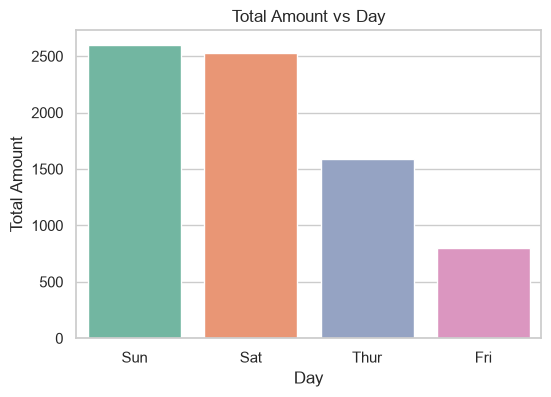

Null hypothesis (H0): There is no significant effect of Day on the mean amount.
Alternative hypothesis (H1): There is a significant effect of Day on the mean amount.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.7935405121541267
  p-value: 6.1070081121326085e-21
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 1.3020317868376277
  p-value: 0.2735798529225529
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  Day                             F=3.004  p=0.030501  -> significant
  Significant difference between groups (reject H0)

Observation & Analysis:
  One-way ANOVA detected a significant effect of Day on Amount (F=3.004, p=0.030501). Group breakdown — Sun (n=114, mean=22.80, total=2599.47, 34.6%);Sat (n=117, mean=21.64, total=2532.04, 33.7%);Fri (n=38, mean=21.03, total=798.95, 10.6%);Thur (n=87, mean=18.28, total=1590.62, 21.1%). The highest average Amount is in the Sun group (22.

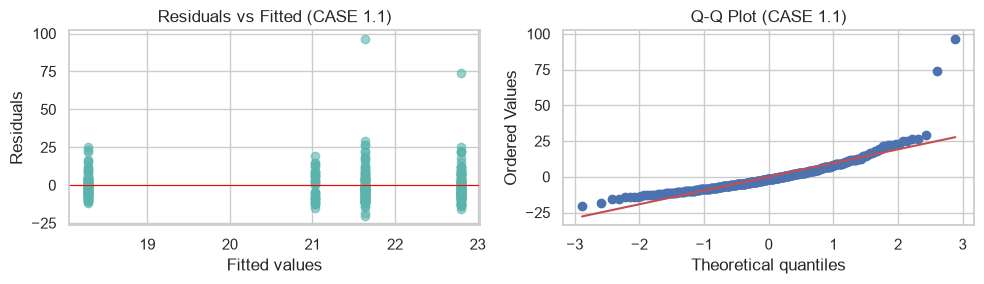



CASE 1.2: Comparing Tip with Day



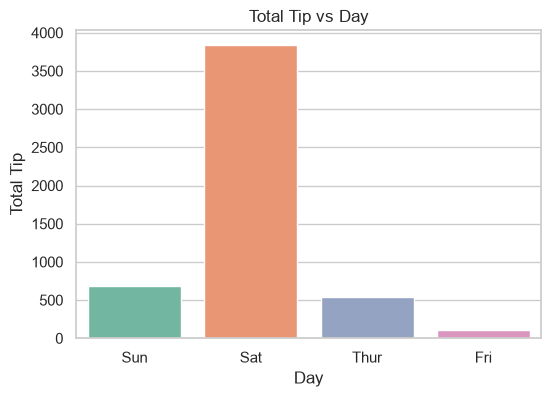

Null hypothesis (H0): There is no significant effect of Day on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Day on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.06070770235074336
  p-value: 2.2447039297341417e-38
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.5677192060914605
  p-value: 0.6366092343237505
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  Day                             F=0.564  p=0.638939  -> not significant
  Failed to find sufficient evidence of a difference between groups


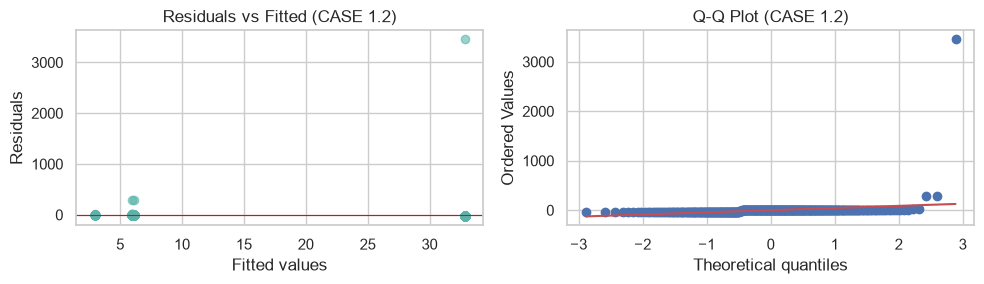



CASE 1.3: Comparing Amount with PartyGroup



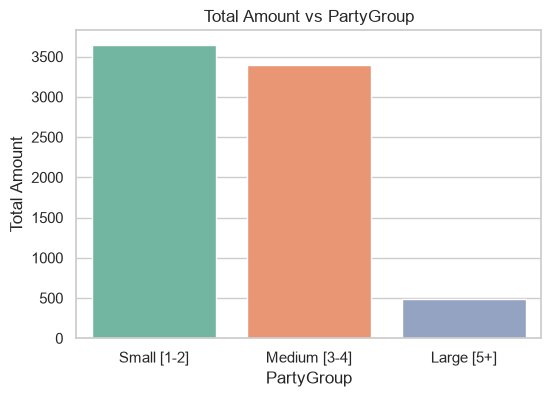

Null hypothesis (H0): There is no significant effect of PartyGroup on the mean amount.
Alternative hypothesis (H1): There is a significant effect of PartyGroup on the mean amount.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.7292181372842288
  p-value: 1.1792124711368879e-23
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 1.1150174713249348
  p-value: 0.3290616234767022
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  PartyGroup                      F=27.885  p=< 0.000001  -> significant
  Significant difference between groups (reject H0)

Observation & Analysis:
  One-way ANOVA detected a significant effect of PartyGroup on Amount (F=27.885, p=< 0.000001). Group breakdown — Medium [3-4] (n=131, mean=25.90, total=3392.58, 45.1%);Large [5+] (n=19, mean=25.46, total=483.68, 6.4%);Small [1-2] (n=206, mean=17.69, total=3644.82, 48.5%). The highest average Amount is in the Medium [3-

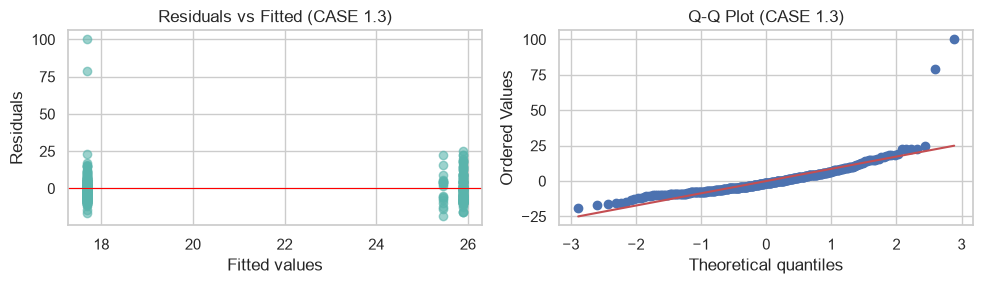



CASE 1.4: Comparing Tip with PartyGroup



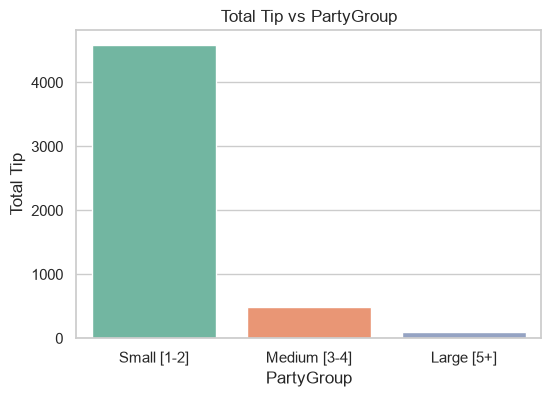

Null hypothesis (H0): There is no significant effect of PartyGroup on the mean tip.
Alternative hypothesis (H1): There is a significant effect of PartyGroup on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.05380611032209276
  p-value: 1.792483256303593e-38
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.4614702838154919
  p-value: 0.6307358900461073
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  PartyGroup                      F=0.424  p=0.654961  -> not significant
  Failed to find sufficient evidence of a difference between groups


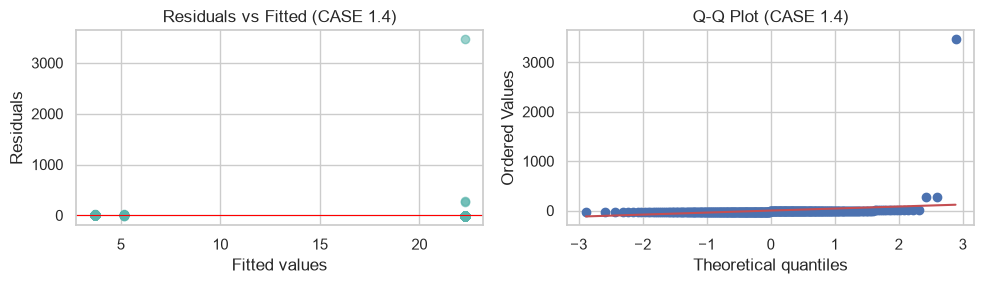



CASE 2.1: Comparing Amount with Day and Time



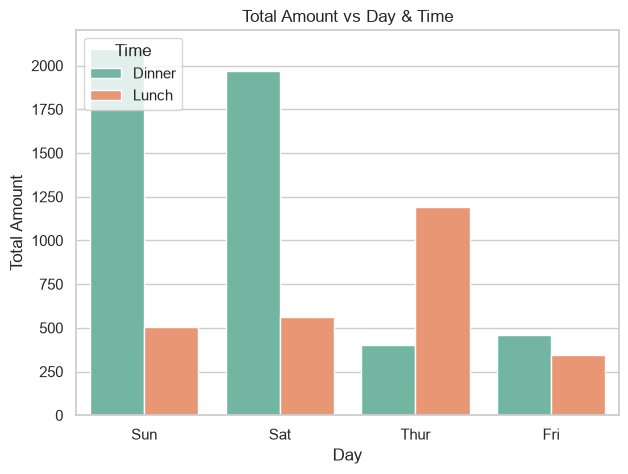

Null hypothesis (H0): There is no significant effect of Day, Time status, or their interaction on the mean amount.
Alternative hypothesis (H1): There is a significant effect of Day, Time status, or their interaction on the mean amount.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.7857390415047171
  p-value: 2.661228730220178e-21
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.7784733090113256
  p-value: 0.6057293645101404
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=1.856  p=0.136742  -> not significant
  Time                                      F=0.239  p=0.625196  -> not significant
  Day x Time                                F=1.879  p=0.132816  -> not significant
  Failed to find sufficient evidence of a difference between groups


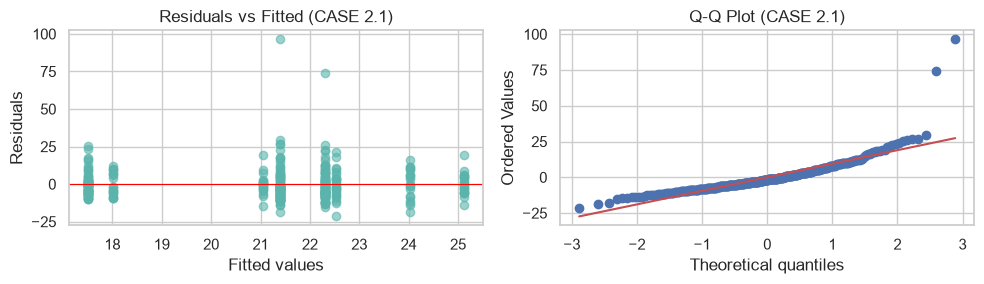



CASE 2.2: Comparing Amount with Smoker and Gender



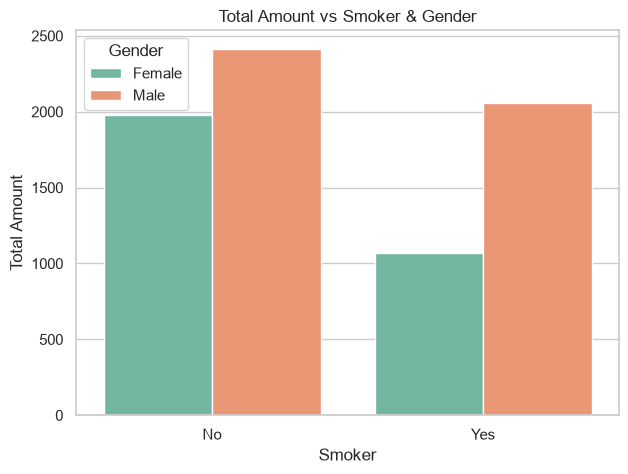

Null hypothesis (H0): There is no significant effect of Smoker, Gender status, or their interaction on the mean amount.
Alternative hypothesis (H1): There is a significant effect of Smoker, Gender status, or their interaction on the mean amount.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.7995382152521153
  p-value: 1.1754357711961819e-20
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 1.754108457215913
  p-value: 0.15565760440287452
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Smoker                                    F=4.335  p=0.038057  -> significant
  Gender                                    F=0.758  p=0.384412  -> not significant
  Smoker x Gender                           F=2.481  p=0.116142  -> not significant
  Significant difference between groups (reject H0)

Observation & Analysis:
  Two-way ANOVA found significant effects on Amount — significant term(s): Smoke

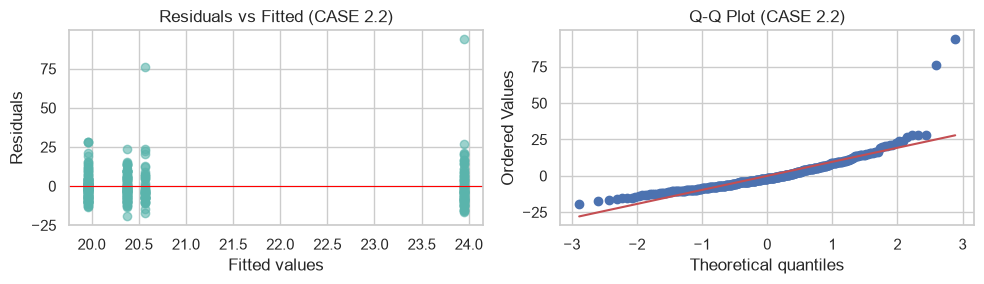



CASE 2.3: Comparing Tip with Day and Smoker



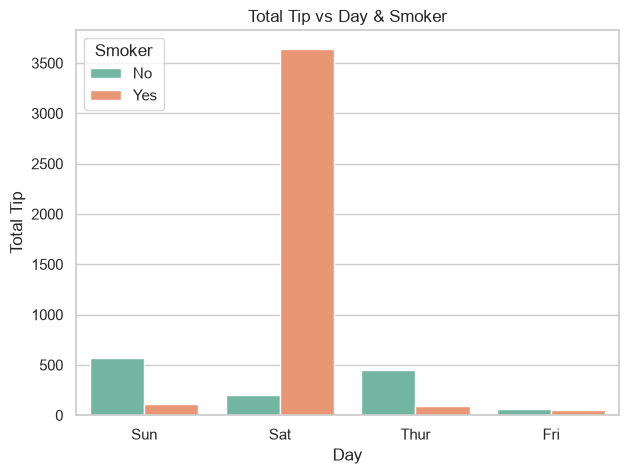

Null hypothesis (H0): There is no significant effect of Day, Smoker status, or their interaction on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Day, Smoker status, or their interaction on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.07593859889833654
  p-value: 3.705747666738951e-38
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.7437856200595728
  p-value: 0.6349696334866246
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=0.485  p=0.692645  -> not significant
  Smoker                                    F=0.990  p=0.320437  -> not significant
  Day x Smoker                              F=0.834  p=0.476106  -> not significant
  Failed to find sufficient evidence of a difference between groups


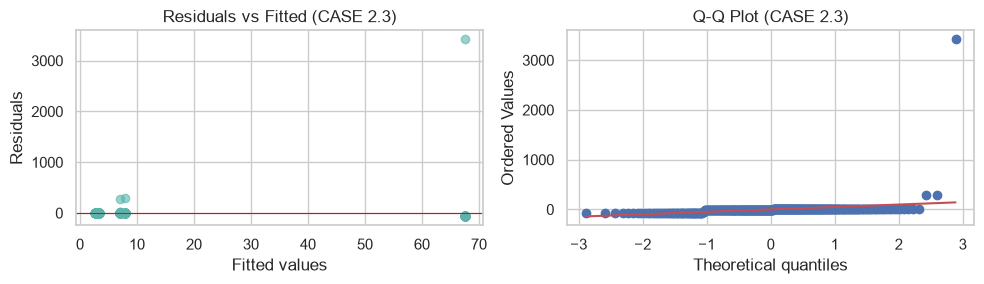



CASE 2.4: Comparing Tip with Gender and Time



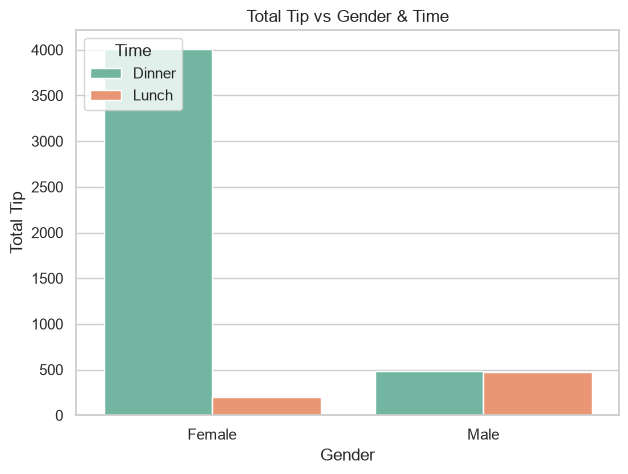

Null hypothesis (H0): There is no significant effect of Gender, Time status, or their interaction on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Gender, Time status, or their interaction on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.07267620079214646
  p-value: 3.3265643999179295e-38
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 1.4309409715601777
  p-value: 0.23346333976242284
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Gender                                    F=1.956  p=0.162863  -> not significant
  Time                                      F=1.080  p=0.299339  -> not significant
  Gender x Time                             F=1.823  p=0.177876  -> not significant
  Failed to find sufficient evidence of a difference between groups


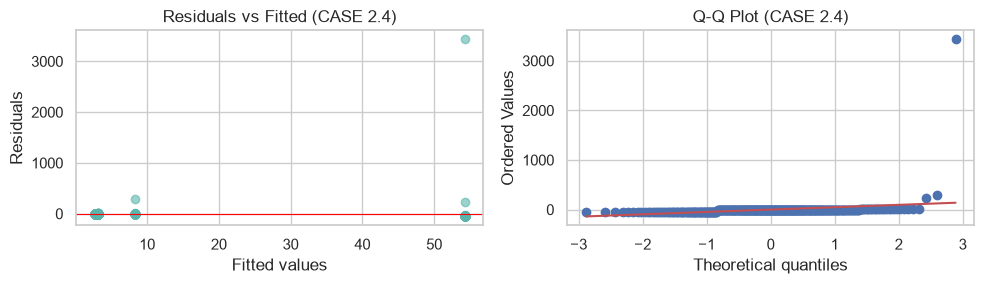



CASE 3.1: Comparing Partysize with Day and Smoker



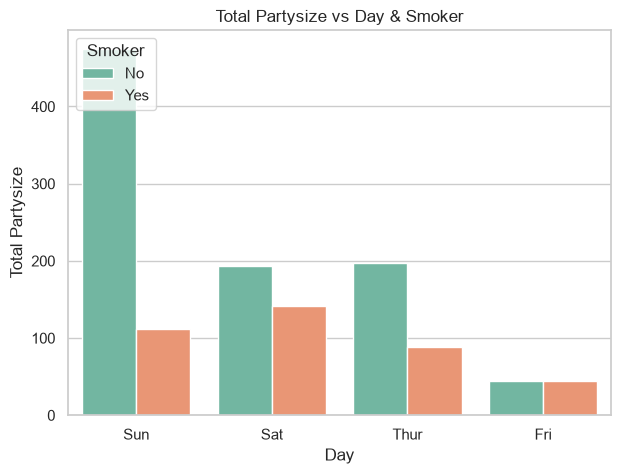

Null hypothesis (H0): There is no significant effect of Day, Smoker status, or their interaction on the mean partysize.
Alternative hypothesis (H1): There is a significant effect of Day, Smoker status, or their interaction on the mean partysize.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.1426170607828386
  p-value: 3.6141970406896584e-37
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.5636878748215433
  p-value: 0.7853220554769551
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=0.904  p=0.439547  -> not significant
  Smoker                                    F=0.768  p=0.381540  -> not significant
  Day x Smoker                              F=0.226  p=0.878007  -> not significant
  Failed to find sufficient evidence of a difference between groups


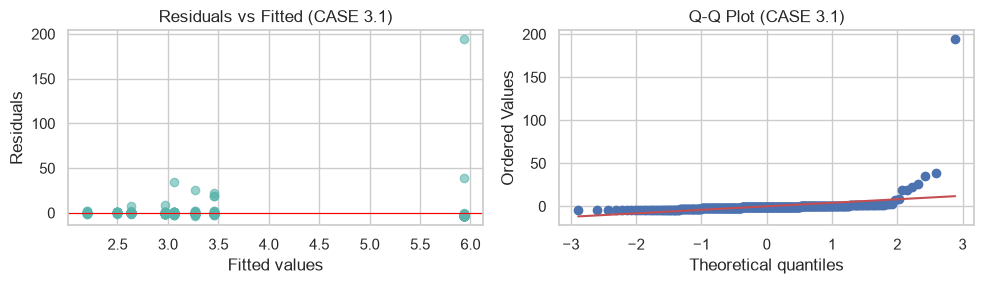



CASE 3.2: Comparing Partysize with Day and Time



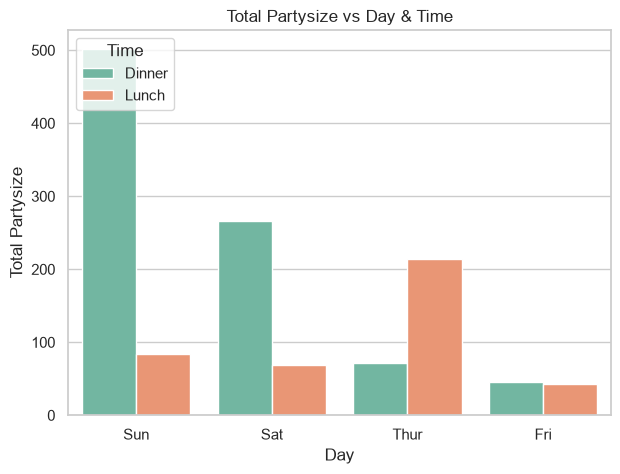

Null hypothesis (H0): There is no significant effect of Day, Time status, or their interaction on the mean partysize.
Alternative hypothesis (H1): There is a significant effect of Day, Time status, or their interaction on the mean partysize.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.13555548559317282
  p-value: 2.8206019171640412e-37
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.47418591999849047
  p-value: 0.8531715460597231
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=0.957  p=0.412992  -> not significant
  Time                                      F=0.139  p=0.709536  -> not significant
  Day x Time                                F=0.029  p=0.993421  -> not significant
  Failed to find sufficient evidence of a difference between groups


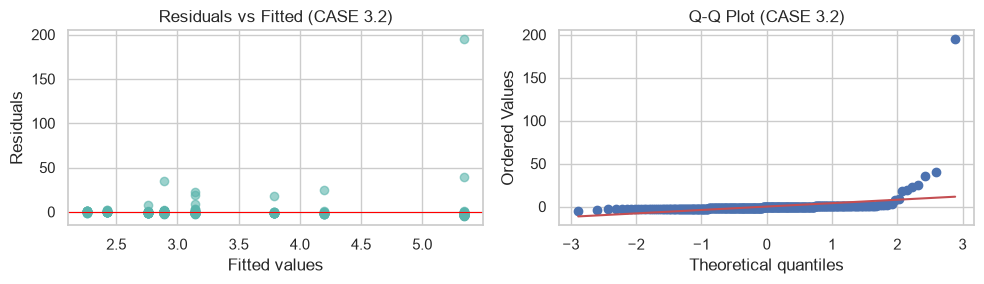



CASE 3.3: Comparing Partysize with Day and Gender



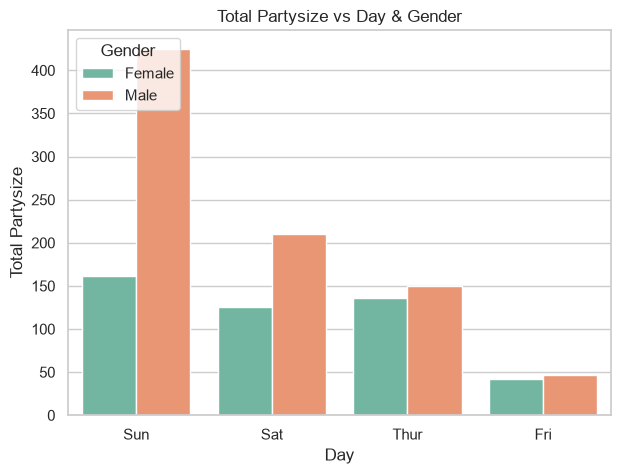

Null hypothesis (H0): There is no significant effect of Day, Gender status, or their interaction on the mean partysize.
Alternative hypothesis (H1): There is a significant effect of Day, Gender status, or their interaction on the mean partysize.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.14103657471623196
  p-value: 3.418621326306369e-37
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.5684219660079927
  p-value: 0.7815364888021721
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=1.012  p=0.387278  -> not significant
  Gender                                    F=0.388  p=0.533850  -> not significant
  Day x Gender                              F=0.155  p=0.926521  -> not significant
  Failed to find sufficient evidence of a difference between groups


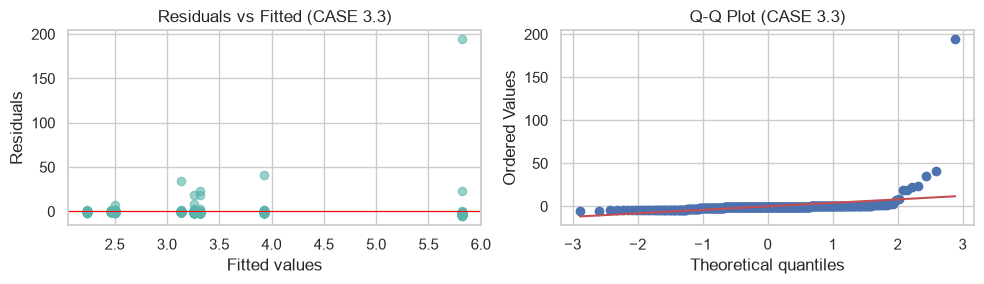




###########################################################################
  SENSITIVITY SUBSET — Tip ANOVA cases (extreme entries excluded)
  322 rows kept  |  34 extreme row(s) removed
  Tip median (full): 2.88  |  Tip median (sensitivity): 2.70
###########################################################################
CASE 1.2 [sensitivity]: Comparing Tip with Day



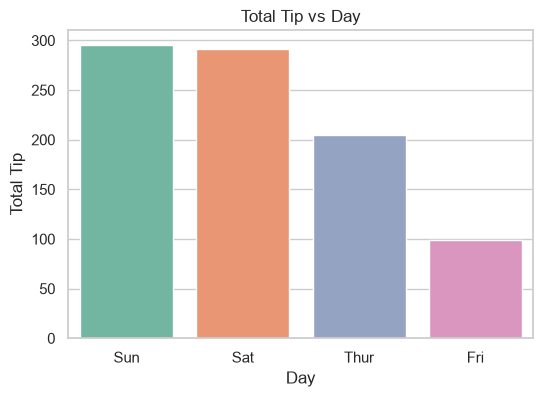

Null hypothesis (H0): There is no significant effect of Day on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Day on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.9764102686934866
  p-value: 3.8949200839501825e-05
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.5788885041597068
  p-value: 0.6292560094570787
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  Day                             F=1.998  p=0.114217  -> not significant
  Failed to find sufficient evidence of a difference between groups


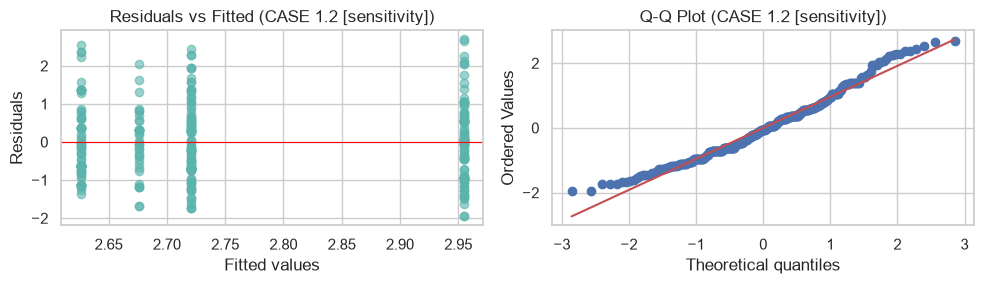



CASE 1.4 [sensitivity]: Comparing Tip with PartyGroup



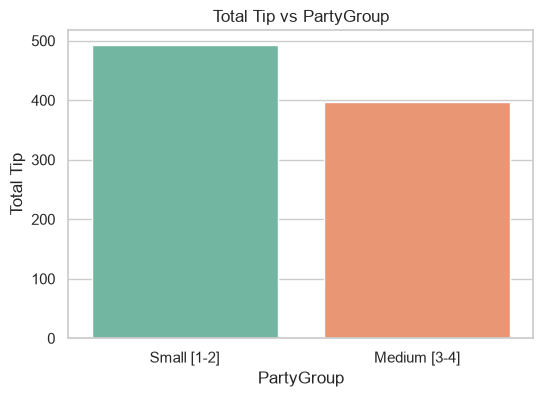

Null hypothesis (H0): There is no significant effect of PartyGroup on the mean tip.
Alternative hypothesis (H1): There is a significant effect of PartyGroup on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.9711116272377373
  p-value: 4.754951306385041e-06
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.05080950388617682
  p-value: 0.8218045016643374
  Variances are not significantly different (fail to reject H0)

One-way ANOVA – per-term results:
  PartyGroup                      F=59.875  p=< 0.000001  -> significant
  Significant difference between groups (reject H0)

Observation & Analysis:
  One-way ANOVA detected a significant effect of PartyGroup on Tip (F=59.875, p=< 0.000001). Group breakdown — Medium [3-4] (n=122, mean=3.26, total=397.58, 44.6%);Small [1-2] (n=200, mean=2.46, total=492.86, 55.4%). The highest average Tip is in the Medium [3-4] group (3.26) and the lowest in the Small [1-2] group (2.46), a 

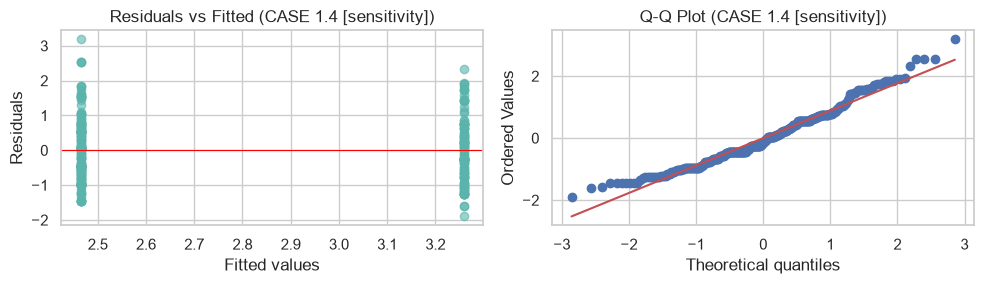



CASE 2.3 [sensitivity]: Comparing Tip with Day and Smoker



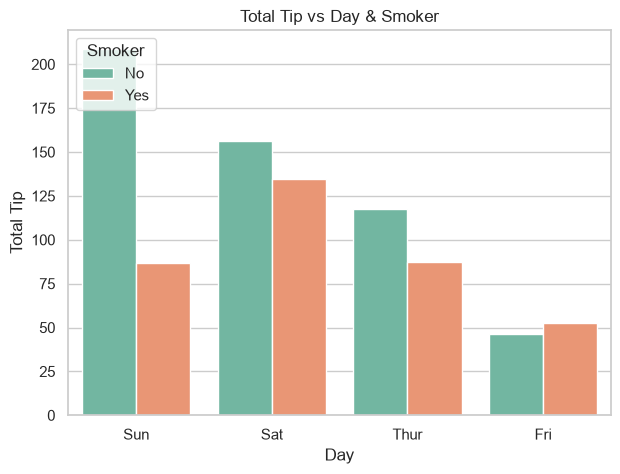

Null hypothesis (H0): There is no significant effect of Day, Smoker status, or their interaction on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Day, Smoker status, or their interaction on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.9808547925817879
  p-value: 0.00027100942564588947
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 1.4398980379016462
  p-value: 0.18860242600049573
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Day                                       F=2.311  p=0.076228  -> not significant
  Smoker                                    F=2.272  p=0.132767  -> not significant
  Day x Smoker                              F=1.860  p=0.136230  -> not significant
  Failed to find sufficient evidence of a difference between groups


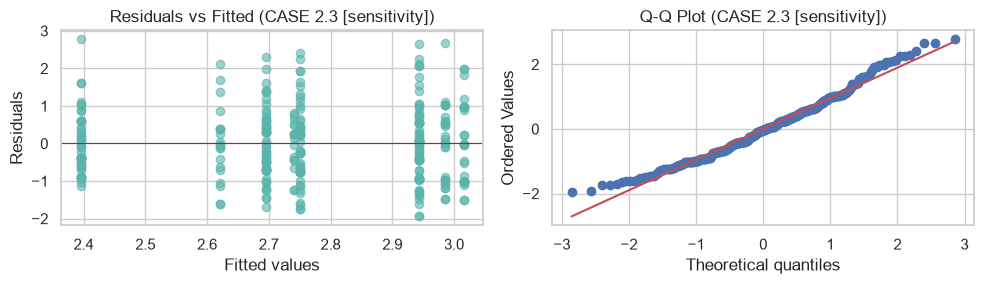



CASE 2.4 [sensitivity]: Comparing Tip with Gender and Time



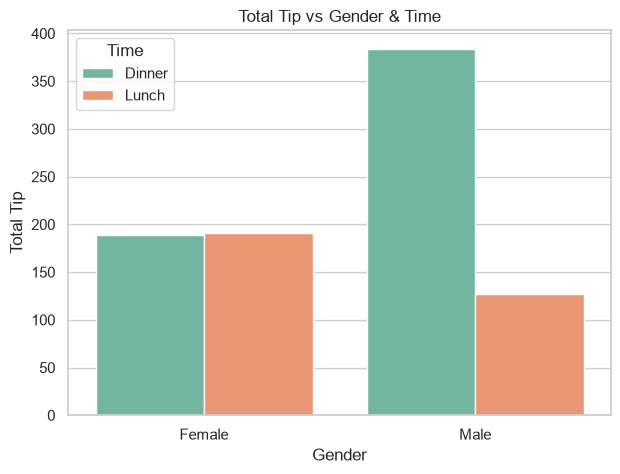

Null hypothesis (H0): There is no significant effect of Gender, Time status, or their interaction on the mean tip.
Alternative hypothesis (H1): There is a significant effect of Gender, Time status, or their interaction on the mean tip.

Shapiro-Wilk Test output:
  Shapiro-Wilk W: 0.9764785783269099
  p-value: 4.007599986939584e-05
  Residuals are not normally distributed (reject H0)

Levene’s Test output:
  Levene's test statistic: 0.969609057312506
  p-value: 0.40727809660311676
  Variances are not significantly different (fail to reject H0)

Two-way ANOVA – per-term results:
  Gender                                    F=0.082  p=0.774543  -> not significant
  Time                                      F=4.140  p=0.042714  -> significant
  Gender x Time                             F=0.789  p=0.375138  -> not significant
  Significant difference between groups (reject H0)

Observation & Analysis:
  Two-way ANOVA found significant effects on Tip — significant term(s): Time (F=4.140, p=0.

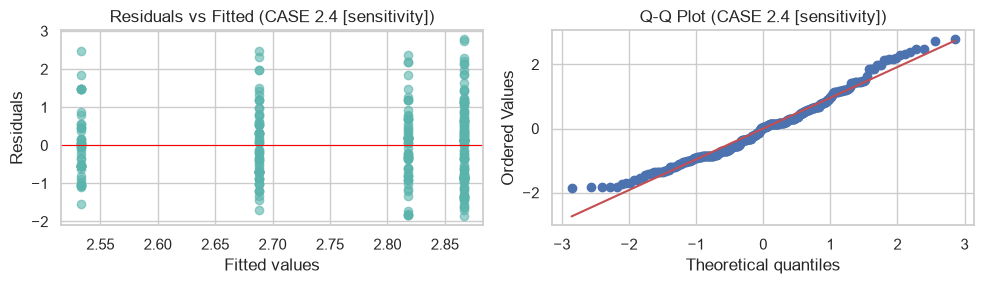

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown
_anova_analyses = []  # collects markdown for each significant ANOVA finding

# =====================================================================
# 1. LOAD DATA & SETUP
# =====================================================================
try:
    df_clean = pd.read_csv('Restaurant_Cleaned.csv')
except FileNotFoundError:
    print("Error: 'Restaurant_Cleaned.csv' not found.")

def group_partysize(size):
    if size <= 2: return 'Small [1-2]'
    elif size <= 4: return 'Medium [3-4]'
    else: return 'Large [5+]'

df_clean['PartyGroup'] = df_clean['Partysize'].apply(group_partysize)
sns.set_theme(style="whitegrid")

# =====================================================================
# 2. MASTER FUNCTION: ONE-WAY ANOVA (Cases 1.x)
# =====================================================================
def full_one_way_analysis(case_name, target, factor, df):
    print(f"\033[1m{case_name}: Comparing {target} with {factor}\033[0m\n")
    
    # Graph
    plt.figure(figsize=(6, 4))
    sns.barplot(x=factor, y=target, data=df, estimator='sum', errorbar=None, palette='Set2')
    plt.title(f"Total {target} vs {factor}", fontsize=12)
    plt.ylabel(f"Total {target}")
    plt.xlabel(factor)
    plt.show()
    
    # Hypotheses
    print(f"\033[1mNull hypothesis (H0):\033[0m There is no significant effect of {factor} on the mean {target.lower()}.")
    print(f"\033[1mAlternative hypothesis (H1):\033[0m There is a significant effect of {factor} on the mean {target.lower()}.\n")
    
    # Model
    model = ols(f"{target} ~ C({factor})", data=df).fit()
    
    # Shapiro
    w, p_shapiro = stats.shapiro(model.resid)
    print("\033[1mShapiro-Wilk Test output:\033[0m")
    print(f"  Shapiro-Wilk W: {w}")
    print(f"  p-value: {p_shapiro}")
    if p_shapiro < 0.05: print("  Residuals are not normally distributed (reject H0)\n")
    else: print("  Residuals are normally distributed (fail to reject H0)\n")
        
    # Levene
    print("\033[1mLevene’s Test output:\033[0m")
    groups = [group[target].dropna() for name, group in df.groupby(factor)]
    stat_lev, p_lev = stats.levene(*groups)
    print(f"  Levene's test statistic: {stat_lev}")
    print(f"  p-value: {p_lev}")
    if p_lev < 0.05: print("  Variances are significantly different (reject H0)\n")
    else: print("  Variances are not significantly different (fail to reject H0)\n")
        
    # ANOVA – per-term reporting
    print("\033[1mOne-way ANOVA – per-term results:\033[0m")
    anova_table = sm.stats.anova_lm(model, typ=2)
    for term, row in anova_table.dropna().iterrows():
        clean_term = term.replace("C(", "").replace(")", "")
        sig = "significant" if row["PR(>F)"] < 0.05 else "not significant"
        print(f"  {clean_term:30s}  F={row['F']:.3f}  p={('< 0.000001' if row['PR(>F)'] < 0.000001 else f"{row['PR(>F)']:.6f}")}  -> {sig}")
    p_vals = anova_table["PR(>F)"].dropna()
    if any(p < 0.05 for p in p_vals):
        print("  \033[1mSignificant difference between groups (reject H0)\033[0m")
        # ── Observation & Analysis ─────────────────────────────────────
        _gstats = df.groupby(factor)[target].agg(["mean","sum","count"]).reset_index()
        _gstats.columns = [factor, "_mean", "_total", "_n"]
        _gstats = _gstats.sort_values("_mean", ascending=False).reset_index(drop=True)
        _grand  = _gstats["_total"].sum()
        _best   = _gstats.iloc[0]
        _worst  = _gstats.iloc[-1]
        _f_val  = anova_table.iloc[0]["F"]
        _p_val  = anova_table.dropna()["PR(>F)"].iloc[0]
        _p_disp = "< 0.000001" if _p_val < 0.000001 else f"{_p_val:.6f}"
        _lines  = []
        for _, _r in _gstats.iterrows():
            _pct = 100 * _r["_total"] / _grand if _grand else 0
            _lines.append(f"{_r[factor]} (n={int(_r['_n'])}, mean={_r['_mean']:.2f}, total={_r['_total']:.2f}, {_pct:.1f}%)")
        _obs_ow = (
            f"One-way ANOVA detected a significant effect of **{factor}** on **{target}** "
            f"(F={_f_val:.3f}, p={_p_disp}). "
            f"Group breakdown — {chr(59).join(_lines)}. "
            f"The highest average {target} is in the **{_best[factor]}** group "
            f"({_best['_mean']:.2f}) and the lowest in the **{_worst[factor]}** group "
            f"({_worst['_mean']:.2f}), a difference of **{_best['_mean']-_worst['_mean']:.2f}**. "
            f"The {_best[factor]} group contributes "
            f"**{100*_best['_total']/_grand:.1f}%** of total {target} "
            f"({_best['_total']:.2f} / {_grand:.2f})."
        )
        _mgmt_ow = (
            f"Since **{factor}** significantly influences **{target}**, prioritise the "
            f"**{_best[factor]}** category for operational and revenue strategies. "
            f"The **{_worst[factor]}** group shows the lowest average {target} "
            f"({_worst['_mean']:.2f}); targeted interventions there could close "
            f"the **{_best['_mean']-_worst['_mean']:.2f}-unit gap** with the best-performing group."
        )
        _anova_analyses.append({
            'title': f"{case_name}: **{target}** by {factor}",
            'obs':   _obs_ow,
            'mgmt':  _mgmt_ow,
            'stats': f"F = {_f_val:.3f} | p = {_p_disp}",
        })
    else:
        print("  \033[1mFailed to find sufficient evidence of a difference between groups\033[0m")
    # Residual diagnostic plots
    import scipy.stats as _sc
    fig_r, (ax1_r, ax2_r) = plt.subplots(1, 2, figsize=(10, 3))
    ax1_r.scatter(model.fittedvalues, model.resid, alpha=0.6, color="#5ab4ac")
    ax1_r.axhline(0, color="red", linewidth=0.8)
    ax1_r.set_xlabel("Fitted values"); ax1_r.set_ylabel("Residuals")
    ax1_r.set_title(f"Residuals vs Fitted ({case_name})")
    _sc.probplot(model.resid, dist="norm", plot=ax2_r)
    ax2_r.set_title(f"Q-Q Plot ({case_name})")
    plt.tight_layout(); plt.show()
    print("\n" + "=" * 75 + "\n")


# =====================================================================
# 3. MASTER FUNCTION: TWO-WAY ANOVA (Cases 2.x and 3.x)
# =====================================================================
def full_two_way_analysis(case_name, target, factor1, factor2, df):
    print(f"\033[1m{case_name}: Comparing {target} with {factor1} and {factor2}\033[0m\n")
    
    # Graph
    plt.figure(figsize=(7, 5))
    sns.barplot(x=factor1, y=target, hue=factor2, data=df, estimator='sum', errorbar=None, palette='Set2')
    plt.title(f"Total {target} vs {factor1} & {factor2}", fontsize=12)
    plt.ylabel(f"Total {target}")
    plt.xlabel(factor1)
    plt.legend(title=factor2, loc='upper left')
    plt.show()
    
    # Hypotheses
    print(f"\033[1mNull hypothesis (H0):\033[0m There is no significant effect of {factor1}, {factor2} status, or their interaction on the mean {target.lower()}.")
    print(f"\033[1mAlternative hypothesis (H1):\033[0m There is a significant effect of {factor1}, {factor2} status, or their interaction on the mean {target.lower()}.\n")
    
    # Model
    model = ols(f"{target} ~ C({factor1}) + C({factor2}) + C({factor1}):C({factor2})", data=df).fit()
    
    # Shapiro
    w, p_shapiro = stats.shapiro(model.resid)
    print("\033[1mShapiro-Wilk Test output:\033[0m")
    print(f"  Shapiro-Wilk W: {w}")
    print(f"  p-value: {p_shapiro}")
    if p_shapiro < 0.05: print("  Residuals are not normally distributed (reject H0)\n")
    else: print("  Residuals are normally distributed (fail to reject H0)\n")
        
    # Levene
    print("\033[1mLevene’s Test output:\033[0m")
    groups = [group[target].dropna() for name, group in df.groupby([factor1, factor2])]
    stat_lev, p_lev = stats.levene(*groups)
    print(f"  Levene's test statistic: {stat_lev}")
    print(f"  p-value: {p_lev}")
    if p_lev < 0.05: print("  Variances are significantly different (reject H0)\n")
    else: print("  Variances are not significantly different (fail to reject H0)\n")
        
    # ANOVA – per-term reporting
    print("\033[1mTwo-way ANOVA – per-term results:\033[0m")
    anova_table = sm.stats.anova_lm(model, typ=2)
    for term, row in anova_table.dropna().iterrows():
        clean_term = term.replace("C(", "").replace(")", "").replace(":", " x ")
        sig = "significant" if row["PR(>F)"] < 0.05 else "not significant"
        print(f"  {clean_term:40s}  F={row['F']:.3f}  p={('< 0.000001' if row['PR(>F)'] < 0.000001 else f"{row['PR(>F)']:.6f}")}  -> {sig}")
    p_vals = anova_table["PR(>F)"].dropna()
    if any(p < 0.05 for p in p_vals):
        print("  \033[1mSignificant difference between groups (reject H0)\033[0m")
        # ── Observation & Analysis (two-way) ───────────────────────────
        _sig_terms = [(t, r["PR(>F)"]) for t, r in anova_table.dropna().iterrows() if r["PR(>F)"] < 0.05]
        _sig_str   = "; ".join(
            f"{t.replace('C(','').replace(')','').replace(':',' x ')} "
            f"(F={anova_table.loc[t,'F']:.3f}, p={"< 0.000001" if p2 < 0.000001 else f'{p2:.6f}'})"
            for t, p2 in _sig_terms
        )
        _g1stats = df.groupby(factor1)[target].agg(["mean","sum","count"]).reset_index()
        _g1stats.columns = [factor1, "_mean", "_total", "_n"]
        _g1stats = _g1stats.sort_values("_mean", ascending=False).reset_index(drop=True)
        _g2stats = df.groupby(factor2)[target].agg(["mean","sum","count"]).reset_index()
        _g2stats.columns = [factor2, "_mean", "_total", "_n"]
        _g2stats = _g2stats.sort_values("_mean", ascending=False).reset_index(drop=True)
        _grand = df[target].sum()
        _best1 = _g1stats.iloc[0]; _best2 = _g2stats.iloc[0]
        _g1_summary = '; '.join(f"{r[factor1]} mean={r['_mean']:.2f}" for _, r in _g1stats.iterrows())
        _g2_summary = '; '.join(f"{r[factor2]} mean={r['_mean']:.2f}" for _, r in _g2stats.iterrows())
        _obs_tw = (
            f"Two-way ANOVA found significant effects on **{target}** — "
            f"significant term(s): {_sig_str}. "
            f"Across **{factor1}**: {_g1_summary}. "
            f"Across **{factor2}**: {_g2_summary}. "
            f"These effects indicate that both **{factor1}** and **{factor2}** "
            f"(and possibly their interaction) shape the **{target}** outcome."
        )
        _mgmt_tw = (
            f"The combination of **{factor1}** and **{factor2}** jointly drives **{target}**. "
            f"Within {factor1}, the **{_best1[factor1]}** level yields the highest average "
            f"({_best1['_mean']:.2f}); within {factor2}, **{_best2[factor2]}** leads "
            f"({_best2['_mean']:.2f}). Prioritise the **{_best1[factor1]} × {_best2[factor2]}** "
            f"combination for maximum {target} impact, and review the lowest-performing "
            f"levels of each factor for targeted improvement opportunities."
        )
        _anova_analyses.append({
            'title': f"{case_name}: **{target}** by {factor1} & {factor2}",
            'obs':   _obs_tw,
            'mgmt':  _mgmt_tw,
            'stats': f"Significant terms: {_sig_str}",
        })
    else:
        print("  \033[1mFailed to find sufficient evidence of a difference between groups\033[0m")
    # Residual diagnostic plots
    import scipy.stats as _sc
    fig_r, (ax1_r, ax2_r) = plt.subplots(1, 2, figsize=(10, 3))
    ax1_r.scatter(model.fittedvalues, model.resid, alpha=0.6, color="#5ab4ac")
    ax1_r.axhline(0, color="red", linewidth=0.8)
    ax1_r.set_xlabel("Fitted values"); ax1_r.set_ylabel("Residuals")
    ax1_r.set_title(f"Residuals vs Fitted ({case_name})")
    _sc.probplot(model.resid, dist="norm", plot=ax2_r)
    ax2_r.set_title(f"Q-Q Plot ({case_name})")
    plt.tight_layout(); plt.show()
    print("\n" + "=" * 75 + "\n")

# =====================================================================
# 4. RUN ALL CASES
# =====================================================================
full_one_way_analysis("CASE 1.1", "Amount", "Day", df_clean)
full_one_way_analysis("CASE 1.2", "Tip", "Day", df_clean)
full_one_way_analysis("CASE 1.3", "Amount", "PartyGroup", df_clean)
full_one_way_analysis("CASE 1.4", "Tip", "PartyGroup", df_clean)

full_two_way_analysis("CASE 2.1", "Amount", "Day", "Time", df_clean)
full_two_way_analysis("CASE 2.2", "Amount", "Smoker", "Gender", df_clean)
full_two_way_analysis("CASE 2.3", "Tip", "Day", "Smoker", df_clean)
full_two_way_analysis("CASE 2.4", "Tip", "Gender", "Time", df_clean)

full_two_way_analysis("CASE 3.1", "Partysize", "Day", "Smoker", df_clean)
full_two_way_analysis("CASE 3.2", "Partysize", "Day", "Time", df_clean)
full_two_way_analysis("CASE 3.3", "Partysize", "Day", "Gender", df_clean)


# =====================================================================
# COMBINED ANOVA MARKDOWN ANALYSIS REPORT
# =====================================================================
if _anova_analyses:
    _md_anova = [
        "# Statistical Analysis Report\n",
        "---\n",
        "## Part 1 — ANOVA Significant Findings\n",
    ]
    for _i, _a in enumerate(_anova_analyses, 1):
        _md_anova.append(f"### Finding {_i}: {_a['title']}")
        _md_anova.append(f"> **Test Statistics:** {_a['stats']}")
        _md_anova.append(f"\n**Observation & Analysis**\n\n{_a['obs']}")
        _md_anova.append(f"\n**Managerial Insight**\n\n{_a['mgmt']}")
        _md_anova.append("\n---")
    _anova_md_str = "\n\n".join(_md_anova)
    display(Markdown(_anova_md_str))
    with open('analysis.md', 'w', encoding='utf-8') as _fmd:
        _fmd.write(_anova_md_str)
    print("[analysis.md] ANOVA section written.")

# =====================================================================
# SENSITIVITY SUBSET: Tip-target ANOVA cases re-run without extreme entries
# Justification: Tip outliers (IQR fence) inflate variance and may distort
# group-mean comparisons. Results below show robustness of conclusions.
# Self-contained: reloads from CSV so no dependency on Cell 3 global state.
# =====================================================================
try:
    # Load only the 7 core columns — avoids boolean flag / encoded columns
    _CORE = ['Amount', 'Tip', 'Gender', 'Smoker', 'Day', 'Time', 'Partysize']
    _df_s = pd.read_csv('Restaurant_Cleaned.csv', usecols=lambda c: c in _CORE)
    _df_s['Tip']       = pd.to_numeric(_df_s['Tip'],       errors='coerce')
    _df_s['Partysize'] = pd.to_numeric(_df_s['Partysize'], errors='coerce')
    _df_s = _df_s.dropna(subset=['Tip', 'Partysize'])

    # Recompute IQR fences (same logic as audit flags in cleaning step)
    _tq1, _tq3 = _df_s['Tip'].quantile([0.25, 0.75])
    _pq1, _pq3 = _df_s['Partysize'].quantile([0.25, 0.75])
    _mask = (
        (_df_s['Tip']       >= _tq1 - 1.5 * (_tq3 - _tq1)) &
        (_df_s['Tip']       <= _tq3 + 1.5 * (_tq3 - _tq1)) &
        (_df_s['Partysize'] >= _pq1 - 1.5 * (_pq3 - _pq1)) &
        (_df_s['Partysize'] <= _pq3 + 1.5 * (_pq3 - _pq1))
    )
    df_sens = _df_s[_mask].copy()
    df_sens['PartyGroup'] = df_sens['Partysize'].apply(group_partysize)

    print("\n" + "#" * 75)
    print("  SENSITIVITY SUBSET — Tip ANOVA cases (extreme entries excluded)")
    print(f"  {len(df_sens)} rows kept  |  {(~_mask).sum()} extreme row(s) removed")
    print(f"  Tip median (full): {_df_s['Tip'].median():.2f}  |  "
          f"Tip median (sensitivity): {df_sens['Tip'].median():.2f}")
    print("#" * 75)

    full_one_way_analysis("CASE 1.2 [sensitivity]", "Tip", "Day",        df_sens)
    full_one_way_analysis("CASE 1.4 [sensitivity]", "Tip", "PartyGroup", df_sens)
    full_two_way_analysis("CASE 2.3 [sensitivity]", "Tip", "Day",    "Smoker", df_sens)
    full_two_way_analysis("CASE 2.4 [sensitivity]", "Tip", "Gender", "Time",   df_sens)
except Exception as _e:
    print(f"Sensitivity analysis could not run: {_e}")


In [43]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

# 1. LOAD DATA
try:
    df_clean = pd.read_csv('Restaurant_Cleaned.csv')
except FileNotFoundError:
    print("Error: 'Restaurant_Cleaned.csv' not found.")

def group_partysize(size):
    if size <= 2: return 'Small [1-2]'
    elif size <= 4: return 'Medium [3-4]'
    else: return 'Large [5+]'

df_clean['PartyGroup'] = df_clean['Partysize'].apply(group_partysize)

retained_h0_anova = []
accepted_h1_anova = []

def record_anova(target, formula, description):
    """Silently runs the ANOVA and categorizes the result for the summary report."""
    model = ols(formula, data=df_clean).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    p_vals = anova_table['PR(>F)'].dropna()
    sig_factors = p_vals[p_vals < 0.05]
    
    if len(sig_factors) > 0:
        # Build a nice string listing exactly which factors were significant
        details = []
        for factor, p in sig_factors.items():
            clean_factor = factor.replace('C(', '').replace(')', '').replace(':', ' x ')
            details.append(f"{clean_factor} (p = {'< 0.000001' if p < 0.000001 else f'{'< 0.000001' if p < 0.000001 else f'{p:.6f}'}'})")
        
        accepted_h1_anova.append(f"   - {target} grouped by {description}: Significant Difference in {', '.join(details)}")
    else:
        # If nothing is significant, log the smallest p-value to show it failed to reach 0.05
        min_p = p_vals.min()
        retained_h0_anova.append(f"   - {target} grouped by {description}: No Difference (min p = {'< 0.000001' if min_p < 0.000001 else f'{'< 0.000001' if min_p < 0.000001 else f'{min_p:.6f}'}'})")

# =====================================================================
# RUN ALL 11 ANOVA CASES SILENTLY
# =====================================================================
record_anova("Amount", "Amount ~ C(Day)", "Day")
record_anova("Tip", "Tip ~ C(Day)", "Day")
record_anova("Amount", "Amount ~ C(PartyGroup)", "PartyGroup")
record_anova("Tip", "Tip ~ C(PartyGroup)", "PartyGroup")

record_anova("Amount", "Amount ~ C(Day) + C(Time) + C(Day):C(Time)", "Day & Time")
record_anova("Amount", "Amount ~ C(Smoker) + C(Gender) + C(Smoker):C(Gender)", "Smoker & Gender")
record_anova("Tip", "Tip ~ C(Day) + C(Smoker) + C(Day):C(Smoker)", "Day & Smoker")
record_anova("Tip", "Tip ~ C(Gender) + C(Time) + C(Gender):C(Time)", "Gender & Time")

record_anova("Partysize", "Partysize ~ C(Day) + C(Smoker) + C(Day):C(Smoker)", "Day & Smoker")
record_anova("Partysize", "Partysize ~ C(Day) + C(Time) + C(Day):C(Time)", "Day & Time")
record_anova("Partysize", "Partysize ~ C(Day) + C(Gender) + C(Day):C(Gender)", "Day & Gender")
# --- NEW AMOUNT COMBINATIONS ---
record_anova("Amount", "Amount ~ C(Day) + C(Smoker) + C(Day):C(Smoker)", "Day & Smoker")
record_anova("Amount", "Amount ~ C(Day) + C(Gender) + C(Day):C(Gender)", "Day & Gender")
record_anova("Amount", "Amount ~ C(Time) + C(PartyGroup) + C(Time):C(PartyGroup)", "Time & PartyGroup")

# --- NEW TIP COMBINATIONS ---
record_anova("Tip", "Tip ~ C(Day) + C(Time) + C(Day):C(Time)", "Day & Time")
record_anova("Tip", "Tip ~ C(Smoker) + C(Gender) + C(Smoker):C(Gender)", "Smoker & Gender")
record_anova("Tip", "Tip ~ C(Time) + C(PartyGroup) + C(Time):C(PartyGroup)", "Time & PartyGroup")



# =====================================================================
# PRINT FINAL SEGREGATED REPORT
# =====================================================================
print("\n=======================================================")
print(" 📊 FINAL ANOVA HYPOTHESIS SEGREGATION REPORT")
print("=======================================================\n")

print("✅ \033[1mFAILED TO FIND SUFFICIENT EVIDENCE OF A DIFFERENCE (H0 not rejected)\033[0m")
print("-" * 75)
for item in retained_h0_anova: 
    print(item)

print("\n❌ \033[1mACCEPT ALTERNATIVE HYPOTHESIS (H1): Significant Differences Found\033[0m")
print("-" * 75)
for item in accepted_h1_anova: 
    print(item)
print("\n=======================================================")



 📊 FINAL ANOVA HYPOTHESIS SEGREGATION REPORT

✅ FAILED TO FIND SUFFICIENT EVIDENCE OF A DIFFERENCE (H0 not rejected)
---------------------------------------------------------------------------
   - Tip grouped by Day: No Difference (min p = 0.638939)
   - Tip grouped by PartyGroup: No Difference (min p = 0.654961)
   - Amount grouped by Day & Time: No Difference (min p = 0.132816)
   - Tip grouped by Day & Smoker: No Difference (min p = 0.320437)
   - Tip grouped by Gender & Time: No Difference (min p = 0.162863)
   - Partysize grouped by Day & Smoker: No Difference (min p = 0.381540)
   - Partysize grouped by Day & Time: No Difference (min p = 0.412992)
   - Partysize grouped by Day & Gender: No Difference (min p = 0.387278)
   - Tip grouped by Day & Time: No Difference (min p = 0.611941)
   - Tip grouped by Smoker & Gender: No Difference (min p = 0.105322)
   - Tip grouped by Time & PartyGroup: No Difference (min p = 0.440156)

❌ ACCEPT ALTERNATIVE HYPOTHESIS (H1): Significant Diffe

Comparing Amount based on Tip (> Median Tip vs <= Median Tip)



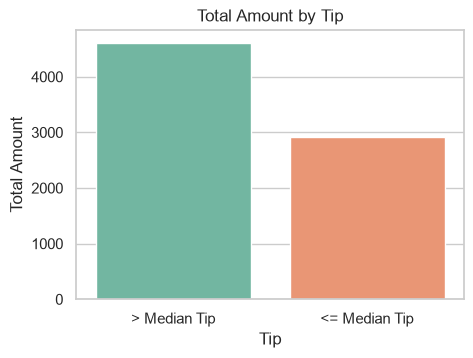

Null hypothesis (H0): There is no significant difference in Amount between > Median Tip and <= Median Tip.
Alternative hypothesis (H1): There is a significant difference in Amount between > Median Tip and <= Median Tip.

Descriptive summary:
  > Median Tip               n= 177  mean=26.0626
  <= Median Tip              n= 179  mean=16.2458
  Mean difference (> Median Tip minus <= Median Tip): 9.8168

Shapiro-Wilk Test output (checking normality):
  > Median Tip Group  W=0.7130  p=< 0.000001
  <= Median Tip Group  W=0.9539  p=0.000014
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 9.5246  p=0.002187
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 9.4636
  p-value:     < 0.000001
  95% CI for mean difference: [7.7744, 11.8591]
  Significant difference between groups (reject H0)

Observation & Analysis:

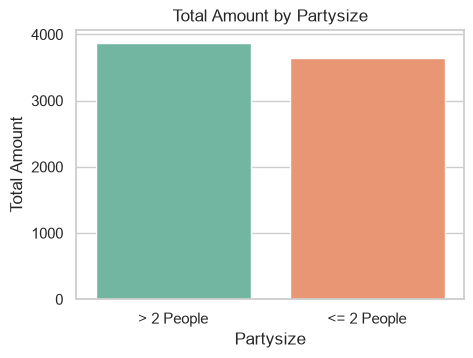

Null hypothesis (H0): There is no significant difference in Amount between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Amount between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=25.8417
  <= 2 People                n= 206  mean=17.6933
  Mean difference (> 2 People minus <= 2 People): 8.1484

Shapiro-Wilk Test output (checking normality):
  > 2 People Group  W=0.9606  p=0.000278
  <= 2 People Group  W=0.5834  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 2.1354  p=0.144824
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 7.7208
  p-value:     < 0.000001
  95% CI for mean difference: [6.0727, 10.2241]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar c

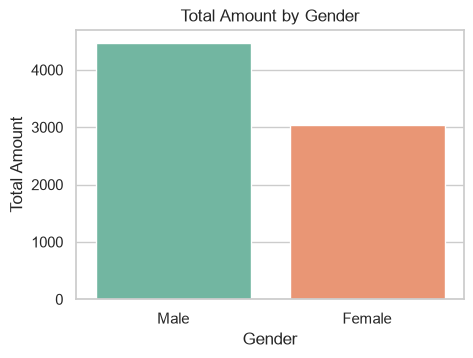

Null hypothesis (H0): There is no significant difference in Amount between Male and Female.
Alternative hypothesis (H1): There is a significant difference in Amount between Male and Female.

Descriptive summary:
  Male                       n= 207  mean=21.6204
  Female                     n= 149  mean=20.4406
  Mean difference (Male minus Female): 1.1798

Shapiro-Wilk Test output (checking normality):
  Male Group  W=0.7744  p=< 0.000001
  Female Group  W=0.8093  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.0885  p=0.766269
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.0199
  p-value:     0.308493
  95% CI for mean difference: [-1.0956, 3.4553]
  Failed to find sufficient evidence of a difference between groups


Comparing Amount based on Smoker (Smoker vs Non-Smoker)



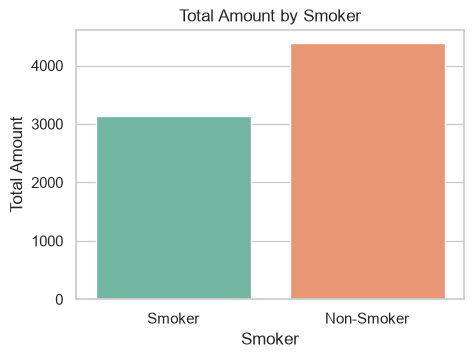

Null hypothesis (H0): There is no significant difference in Amount between Smoker and Non-Smoker.
Alternative hypothesis (H1): There is a significant difference in Amount between Smoker and Non-Smoker.

Descriptive summary:
  Smoker                     n= 138  mean=22.6756
  Non-Smoker                 n= 218  mean=20.1461
  Mean difference (Smoker minus Non-Smoker): 2.5295

Shapiro-Wilk Test output (checking normality):
  Smoker Group  W=0.7186  p=< 0.000001
  Non-Smoker Group  W=0.9579  p=0.000005
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 6.2508  p=0.012865
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.9168
  p-value:     0.056712
  95% CI for mean difference: [-0.0730, 5.1319]
  Failed to find sufficient evidence of a difference between groups


Comparing Amount based on Time (Dinner vs Lu

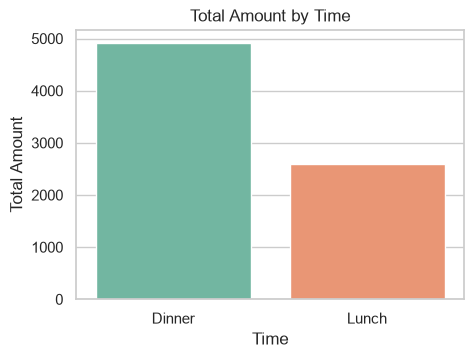

Null hypothesis (H0): There is no significant difference in Amount between Dinner and Lunch.
Alternative hypothesis (H1): There is a significant difference in Amount between Dinner and Lunch.

Descriptive summary:
  Dinner                     n= 224  mean=21.9746
  Lunch                      n= 132  mean=19.6876
  Mean difference (Dinner minus Lunch): 2.2871

Shapiro-Wilk Test output (checking normality):
  Dinner Group  W=0.7438  p=< 0.000001
  Lunch Group  W=0.9572  p=0.000380
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.8874  p=0.346826
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 2.0965
  p-value:     0.036767
  95% CI for mean difference: [0.1414, 4.4327]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart comparison of total Amount shows that 

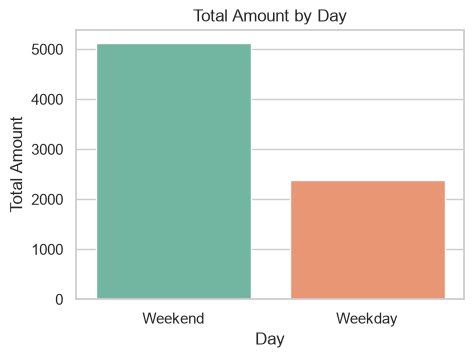

Null hypothesis (H0): There is no significant difference in Amount between Weekend and Weekday.
Alternative hypothesis (H1): There is a significant difference in Amount between Weekend and Weekday.

Descriptive summary:
  Weekend                    n= 231  mean=22.2143
  Weekday                    n= 125  mean=19.1166
  Mean difference (Weekend minus Weekday): 3.0978

Shapiro-Wilk Test output (checking normality):
  Weekend Group  W=0.7531  p=< 0.000001
  Weekday Group  W=0.9476  p=0.000103
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.3006  p=0.254869
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 2.8729
  p-value:     0.004327
  95% CI for mean difference: [0.9767, 5.2188]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart comparison of total Amount

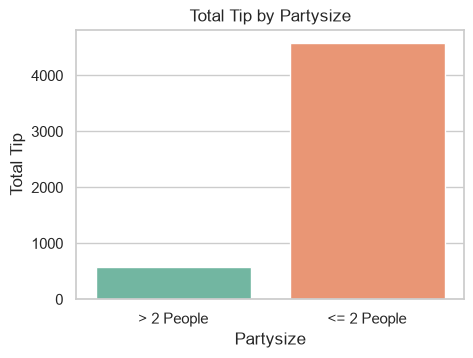

Null hypothesis (H0): There is no significant difference in Tip between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Tip between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=3.8851
  <= 2 People                n= 206  mean=22.2668
  Mean difference (> 2 People minus <= 2 People): -18.3817

  [NOTE] Tip-based inferential claims are set aside until extreme
  entries are verified (see audit flags in the cleaning step).
  Interim median -- > 2 People: 3.34  |  <= 2 People: 2.39


Comparing Tip based on Gender (Male vs Female)



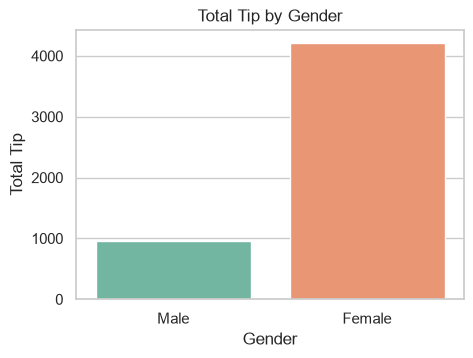

Null hypothesis (H0): There is no significant difference in Tip between Male and Female.
Alternative hypothesis (H1): There is a significant difference in Tip between Male and Female.

Descriptive summary:
  Male                       n= 207  mean=4.6029
  Female                     n= 149  mean=28.3015
  Mean difference (Male minus Female): -23.6987

  [NOTE] Tip-based inferential claims are set aside until extreme
  entries are verified (see audit flags in the cleaning step).
  Interim median -- Male: 2.90  |  Female: 2.83


Comparing Tip based on Smoker (Smoker vs Non-Smoker)



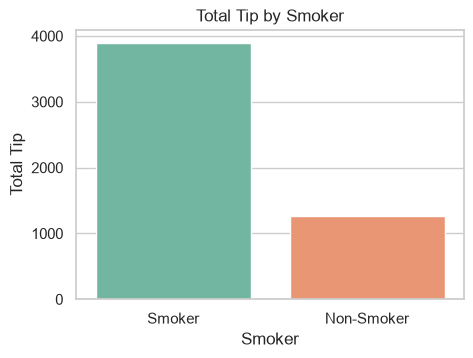

Null hypothesis (H0): There is no significant difference in Tip between Smoker and Non-Smoker.
Alternative hypothesis (H1): There is a significant difference in Tip between Smoker and Non-Smoker.

Descriptive summary:
  Smoker                     n= 138  mean=28.2538
  Non-Smoker                 n= 218  mean=5.8289
  Mean difference (Smoker minus Non-Smoker): 22.4250

  [NOTE] Tip-based inferential claims are set aside until extreme
  entries are verified (see audit flags in the cleaning step).
  Interim median -- Smoker: 2.92  |  Non-Smoker: 2.85


Comparing Tip based on Time (Dinner vs Lunch)



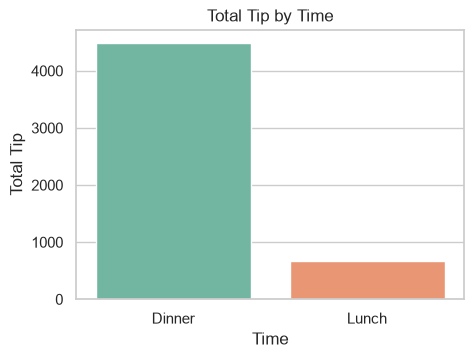

Null hypothesis (H0): There is no significant difference in Tip between Dinner and Lunch.
Alternative hypothesis (H1): There is a significant difference in Tip between Dinner and Lunch.

Descriptive summary:
  Dinner                     n= 224  mean=20.0609
  Lunch                      n= 132  mean=5.1217
  Mean difference (Dinner minus Lunch): 14.9392

  [NOTE] Tip-based inferential claims are set aside until extreme
  entries are verified (see audit flags in the cleaning step).
  Interim median -- Dinner: 3.00  |  Lunch: 2.54


Comparing Tip based on Day (Weekend vs Weekday)



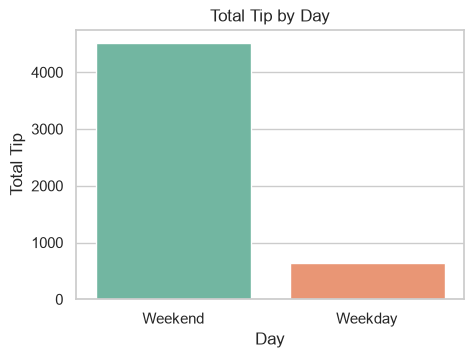

Null hypothesis (H0): There is no significant difference in Tip between Weekend and Weekday.
Alternative hypothesis (H1): There is a significant difference in Tip between Weekend and Weekday.

Descriptive summary:
  Weekend                    n= 231  mean=19.5755
  Weekday                    n= 125  mean=5.1822
  Mean difference (Weekend minus Weekday): 14.3933

  [NOTE] Tip-based inferential claims are set aside until extreme
  entries are verified (see audit flags in the cleaning step).
  Interim median -- Weekend: 3.00  |  Weekday: 2.59


Comparing Gender (Male=1) based on Tip (> Median Tip vs <= Median Tip)



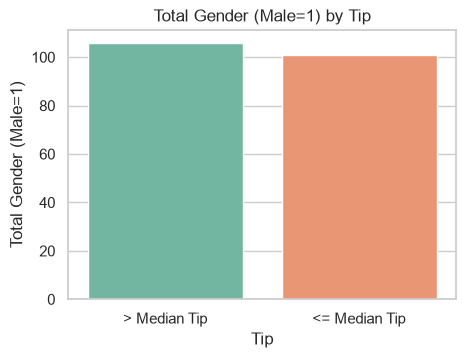

Null hypothesis (H0): There is no significant difference in Gender (Male=1) between > Median Tip and <= Median Tip.
Alternative hypothesis (H1): There is a significant difference in Gender (Male=1) between > Median Tip and <= Median Tip.

Descriptive summary:
  > Median Tip               n= 177  mean=0.5989
  <= Median Tip              n= 179  mean=0.5642
  Mean difference (> Median Tip minus <= Median Tip): 0.0346

Shapiro-Wilk Test output (checking normality):
  > Median Tip Group  W=0.6220  p=< 0.000001
  <= Median Tip Group  W=0.6304  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.4365  p=0.509254
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 0.6607
  p-value:     0.509226
  95% CI for mean difference: [-0.0684, 0.1377]
  Failed to find sufficient evidence of a difference bet

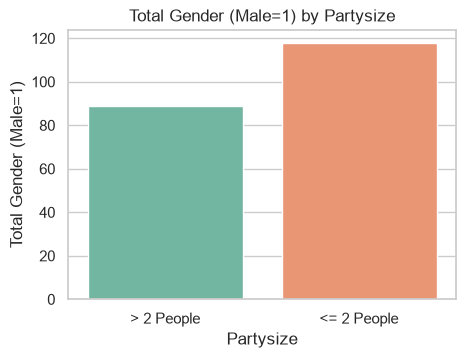

Null hypothesis (H0): There is no significant difference in Gender (Male=1) between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Gender (Male=1) between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=0.5933
  <= 2 People                n= 206  mean=0.5728
  Mean difference (> 2 People minus <= 2 People): 0.0205

Shapiro-Wilk Test output (checking normality):
  > 2 People Group  W=0.6236  p=< 0.000001
  <= 2 People Group  W=0.6287  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.1494  p=0.699375
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 0.3869
  p-value:     0.699122
  95% CI for mean difference: [-0.0838, 0.1249]
  Failed to find sufficient evidence of a difference between groups


Co

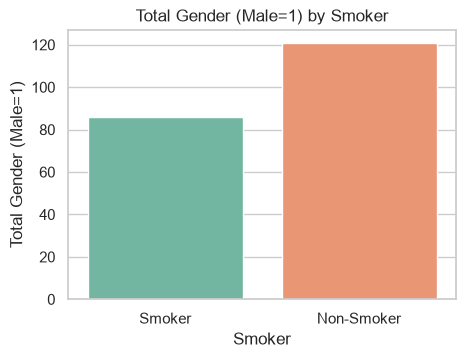

Null hypothesis (H0): There is no significant difference in Gender (Male=1) between Smoker and Non-Smoker.
Alternative hypothesis (H1): There is a significant difference in Gender (Male=1) between Smoker and Non-Smoker.

Descriptive summary:
  Smoker                     n= 138  mean=0.6232
  Non-Smoker                 n= 218  mean=0.5550
  Mean difference (Smoker minus Non-Smoker): 0.0681

Shapiro-Wilk Test output (checking normality):
  Smoker Group  W=0.6139  p=< 0.000001
  Non-Smoker Group  W=0.6320  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.6106  p=0.205240
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.2759
  p-value:     0.202973
  95% CI for mean difference: [-0.0370, 0.1732]
  Failed to find sufficient evidence of a difference between groups


Comparing Gender (Male

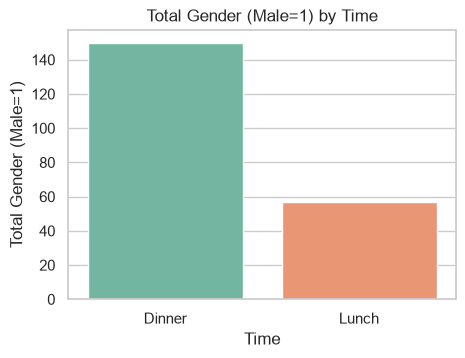

Null hypothesis (H0): There is no significant difference in Gender (Male=1) between Dinner and Lunch.
Alternative hypothesis (H1): There is a significant difference in Gender (Male=1) between Dinner and Lunch.

Descriptive summary:
  Dinner                     n= 224  mean=0.6696
  Lunch                      n= 132  mean=0.4318
  Mean difference (Dinner minus Lunch): 0.2378

Shapiro-Wilk Test output (checking normality):
  Dinner Group  W=0.5932  p=< 0.000001
  Lunch Group  W=0.6296  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 3.6938  p=0.055416
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 4.4432
  p-value:     0.000013
  95% CI for mean difference: [0.1324, 0.3432]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart comparison of total 

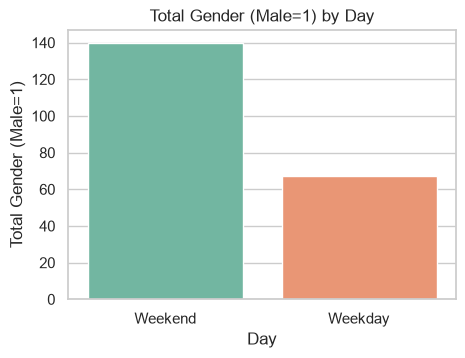

Null hypothesis (H0): There is no significant difference in Gender (Male=1) between Weekend and Weekday.
Alternative hypothesis (H1): There is a significant difference in Gender (Male=1) between Weekend and Weekday.

Descriptive summary:
  Weekend                    n= 231  mean=0.6061
  Weekday                    n= 125  mean=0.5360
  Mean difference (Weekend minus Weekday): 0.0701

Shapiro-Wilk Test output (checking normality):
  Weekend Group  W=0.6199  p=< 0.000001
  Weekday Group  W=0.6345  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.6342  p=0.201955
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.2699
  p-value:     0.205302
  95% CI for mean difference: [-0.0386, 0.1787]
  Failed to find sufficient evidence of a difference between groups


Comparing Smoker (Yes=1) based

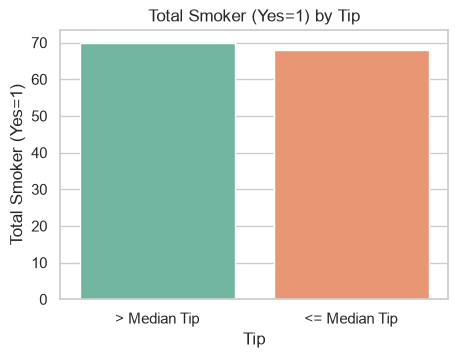

Null hypothesis (H0): There is no significant difference in Smoker (Yes=1) between > Median Tip and <= Median Tip.
Alternative hypothesis (H1): There is a significant difference in Smoker (Yes=1) between > Median Tip and <= Median Tip.

Descriptive summary:
  > Median Tip               n= 177  mean=0.3955
  <= Median Tip              n= 179  mean=0.3799
  Mean difference (> Median Tip minus <= Median Tip): 0.0156

Shapiro-Wilk Test output (checking normality):
  > Median Tip Group  W=0.6203  p=< 0.000001
  <= Median Tip Group  W=0.6151  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.0907  p=0.763519
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 0.3011
  p-value:     0.763529
  95% CI for mean difference: [-0.0863, 0.1174]
  Failed to find sufficient evidence of a difference betwe

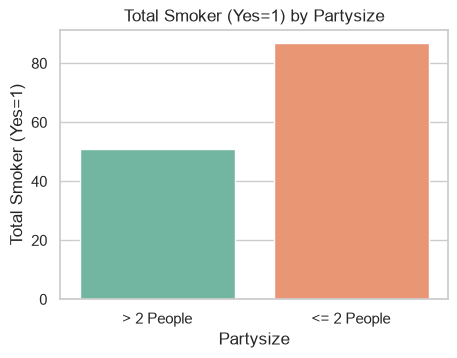

Null hypothesis (H0): There is no significant difference in Smoker (Yes=1) between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Smoker (Yes=1) between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=0.3400
  <= 2 People                n= 206  mean=0.4223
  Mean difference (> 2 People minus <= 2 People): -0.0823

Shapiro-Wilk Test output (checking normality):
  > 2 People Group  W=0.5980  p=< 0.000001
  <= 2 People Group  W=0.6276  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 2.4819  p=0.116059
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: -1.5856
  p-value:     0.113797
  95% CI for mean difference: [-0.1845, 0.0198]
  Failed to find sufficient evidence of a difference between groups


Co

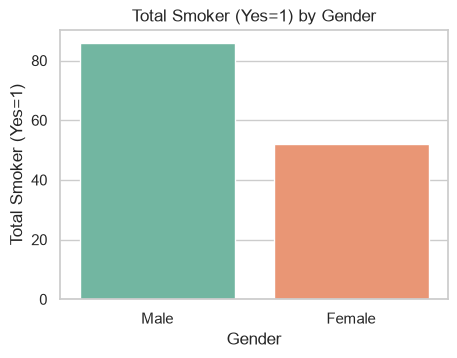

Null hypothesis (H0): There is no significant difference in Smoker (Yes=1) between Male and Female.
Alternative hypothesis (H1): There is a significant difference in Smoker (Yes=1) between Male and Female.

Descriptive summary:
  Male                       n= 207  mean=0.4155
  Female                     n= 149  mean=0.3490
  Mean difference (Male minus Female): 0.0665

Shapiro-Wilk Test output (checking normality):
  Male Group  W=0.6260  p=< 0.000001
  Female Group  W=0.6023  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.6106  p=0.205240
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.2758
  p-value:     0.202928
  95% CI for mean difference: [-0.0360, 0.1690]
  Failed to find sufficient evidence of a difference between groups


Comparing Smoker (Yes=1) based on Time (Dinner v

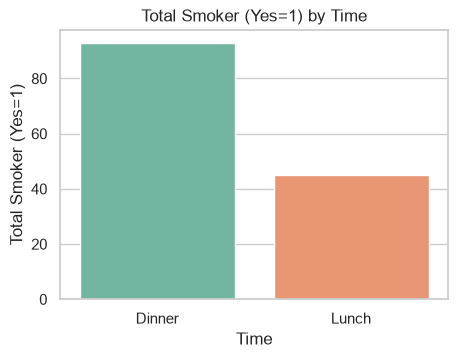

Null hypothesis (H0): There is no significant difference in Smoker (Yes=1) between Dinner and Lunch.
Alternative hypothesis (H1): There is a significant difference in Smoker (Yes=1) between Dinner and Lunch.

Descriptive summary:
  Dinner                     n= 224  mean=0.4152
  Lunch                      n= 132  mean=0.3409
  Mean difference (Dinner minus Lunch): 0.0743

Shapiro-Wilk Test output (checking normality):
  Dinner Group  W=0.6259  p=< 0.000001
  Lunch Group  W=0.5985  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.9296  p=0.165673
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.4026
  p-value:     0.161844
  95% CI for mean difference: [-0.0300, 0.1785]
  Failed to find sufficient evidence of a difference between groups


Comparing Smoker (Yes=1) based on Day (Weeke

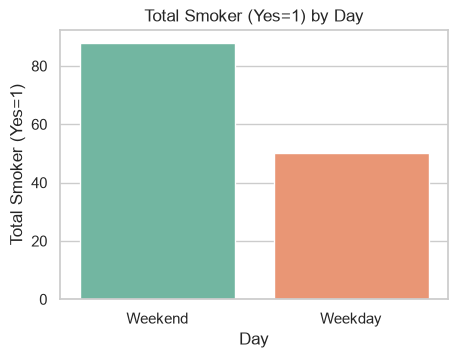

Null hypothesis (H0): There is no significant difference in Smoker (Yes=1) between Weekend and Weekday.
Alternative hypothesis (H1): There is a significant difference in Smoker (Yes=1) between Weekend and Weekday.

Descriptive summary:
  Weekend                    n= 231  mean=0.3810
  Weekday                    n= 125  mean=0.4000
  Mean difference (Weekend minus Weekday): -0.0190

Shapiro-Wilk Test output (checking normality):
  Weekend Group  W=0.6155  p=< 0.000001
  Weekday Group  W=0.6217  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.1233  p=0.725674
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: -0.3501
  p-value:     0.726591
  95% CI for mean difference: [-0.1262, 0.0881]
  Failed to find sufficient evidence of a difference between groups


Comparing Time (Dinner=1) base

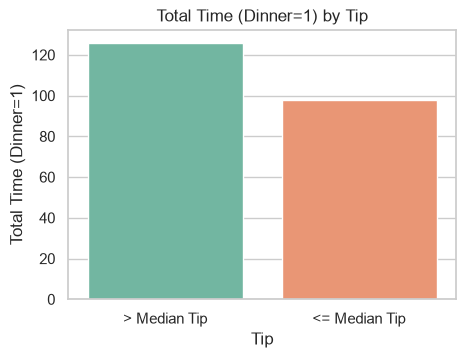

Null hypothesis (H0): There is no significant difference in Time (Dinner=1) between > Median Tip and <= Median Tip.
Alternative hypothesis (H1): There is a significant difference in Time (Dinner=1) between > Median Tip and <= Median Tip.

Descriptive summary:
  > Median Tip               n= 177  mean=0.7119
  <= Median Tip              n= 179  mean=0.5475
  Mean difference (> Median Tip minus <= Median Tip): 0.1644

Shapiro-Wilk Test output (checking normality):
  > Median Tip Group  W=0.5675  p=< 0.000001
  <= Median Tip Group  W=0.6331  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 10.5550  p=0.001270
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 3.2506
  p-value:     0.001263
  95% CI for mean difference: [0.0649, 0.2638]
  Significant difference between groups (reject H0)

Observa

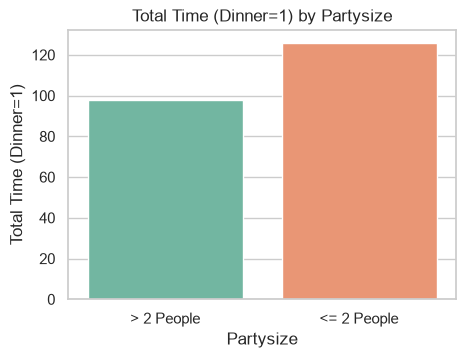

Null hypothesis (H0): There is no significant difference in Time (Dinner=1) between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Time (Dinner=1) between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=0.6533
  <= 2 People                n= 206  mean=0.6117
  Mean difference (> 2 People minus <= 2 People): 0.0417

Shapiro-Wilk Test output (checking normality):
  > 2 People Group  W=0.6013  p=< 0.000001
  <= 2 People Group  W=0.6180  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.6439  p=0.422827
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 0.8054
  p-value:     0.421200
  95% CI for mean difference: [-0.0601, 0.1435]
  Failed to find sufficient evidence of a difference between groups


Co

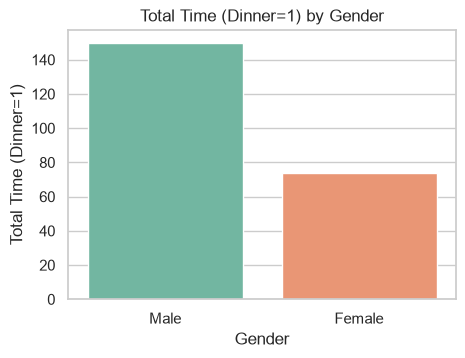

Null hypothesis (H0): There is no significant difference in Time (Dinner=1) between Male and Female.
Alternative hypothesis (H1): There is a significant difference in Time (Dinner=1) between Male and Female.

Descriptive summary:
  Male                       n= 207  mean=0.7246
  Female                     n= 149  mean=0.4966
  Mean difference (Male minus Female): 0.2280

Shapiro-Wilk Test output (checking normality):
  Male Group  W=0.5585  p=< 0.000001
  Female Group  W=0.6364  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 19.1179  p=0.000016
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 4.4225
  p-value:     0.000014
  95% CI for mean difference: [0.1265, 0.3295]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart comparison of total Time (D

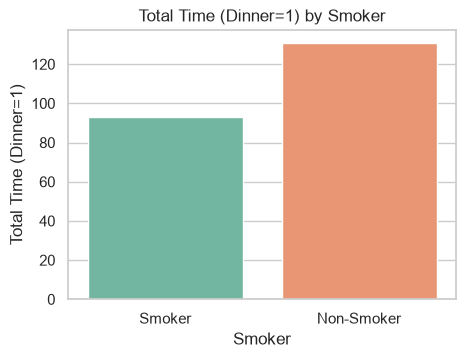

Null hypothesis (H0): There is no significant difference in Time (Dinner=1) between Smoker and Non-Smoker.
Alternative hypothesis (H1): There is a significant difference in Time (Dinner=1) between Smoker and Non-Smoker.

Descriptive summary:
  Smoker                     n= 138  mean=0.6739
  Non-Smoker                 n= 218  mean=0.6009
  Mean difference (Smoker minus Non-Smoker): 0.0730

Shapiro-Wilk Test output (checking normality):
  Smoker Group  W=0.5908  p=< 0.000001
  Non-Smoker Group  W=0.6215  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.9296  p=0.165673
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.4024
  p-value:     0.161822
  95% CI for mean difference: [-0.0294, 0.1754]
  Failed to find sufficient evidence of a difference between groups


Comparing Time (Dinner

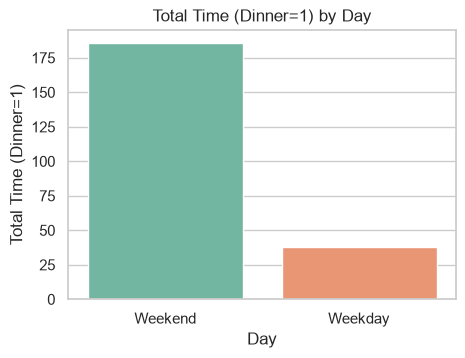

Null hypothesis (H0): There is no significant difference in Time (Dinner=1) between Weekend and Weekday.
Alternative hypothesis (H1): There is a significant difference in Time (Dinner=1) between Weekend and Weekday.

Descriptive summary:
  Weekend                    n= 231  mean=0.8052
  Weekday                    n= 125  mean=0.3040
  Mean difference (Weekend minus Weekday): 0.5012

Shapiro-Wilk Test output (checking normality):
  Weekend Group  W=0.4838  p=< 0.000001
  Weekday Group  W=0.5779  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 5.4618  p=0.019993
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 10.2556
  p-value:     < 0.000001
  95% CI for mean difference: [0.4049, 0.5975]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart compariso

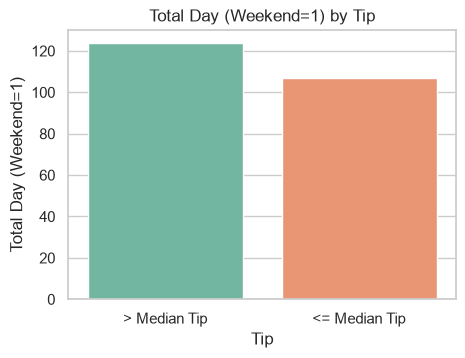

Null hypothesis (H0): There is no significant difference in Day (Weekend=1) between > Median Tip and <= Median Tip.
Alternative hypothesis (H1): There is a significant difference in Day (Weekend=1) between > Median Tip and <= Median Tip.

Descriptive summary:
  > Median Tip               n= 177  mean=0.7006
  <= Median Tip              n= 179  mean=0.5978
  Mean difference (> Median Tip minus <= Median Tip): 0.1028

Shapiro-Wilk Test output (checking normality):
  > Median Tip Group  W=0.5751  p=< 0.000001
  <= Median Tip Group  W=0.6224  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 4.1529  p=0.042305
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 2.0387
  p-value:     0.042229
  95% CI for mean difference: [0.0036, 0.2020]
  Significant difference between groups (reject H0)

Observat

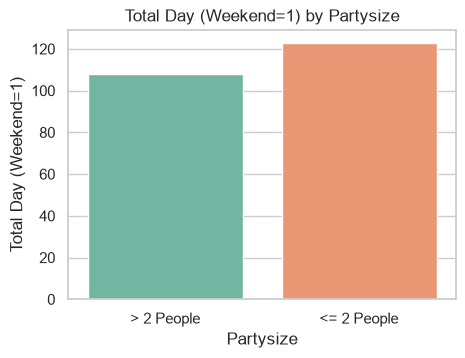

Null hypothesis (H0): There is no significant difference in Day (Weekend=1) between > 2 People and <= 2 People.
Alternative hypothesis (H1): There is a significant difference in Day (Weekend=1) between > 2 People and <= 2 People.

Descriptive summary:
  > 2 People                 n= 150  mean=0.7200
  <= 2 People                n= 206  mean=0.5971
  Mean difference (> 2 People minus <= 2 People): 0.1229

Shapiro-Wilk Test output (checking normality):
  > 2 People Group  W=0.5618  p=< 0.000001
  <= 2 People Group  W=0.6226  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 5.8172  p=0.016379
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 2.4453
  p-value:     0.014986
  95% CI for mean difference: [0.0240, 0.2218]
  Significant difference between groups (reject H0)

Observation & Analysis:


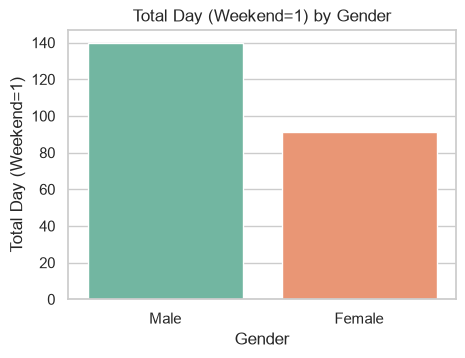

Null hypothesis (H0): There is no significant difference in Day (Weekend=1) between Male and Female.
Alternative hypothesis (H1): There is a significant difference in Day (Weekend=1) between Male and Female.

Descriptive summary:
  Male                       n= 207  mean=0.6763
  Female                     n= 149  mean=0.6107
  Mean difference (Male minus Female): 0.0656

Shapiro-Wilk Test output (checking normality):
  Male Group  W=0.5895  p=< 0.000001
  Female Group  W=0.6183  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 1.6342  p=0.201955
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 1.2696
  p-value:     0.205178
  95% CI for mean difference: [-0.0361, 0.1672]
  Failed to find sufficient evidence of a difference between groups


Comparing Day (Weekend=1) based on Smoker (Smo

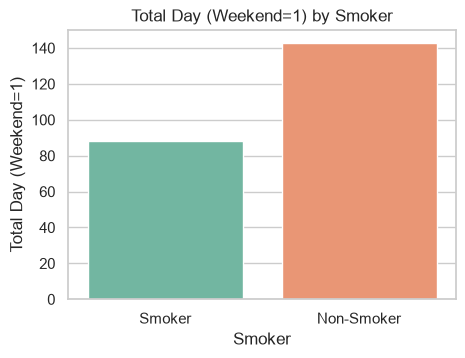

Null hypothesis (H0): There is no significant difference in Day (Weekend=1) between Smoker and Non-Smoker.
Alternative hypothesis (H1): There is a significant difference in Day (Weekend=1) between Smoker and Non-Smoker.

Descriptive summary:
  Smoker                     n= 138  mean=0.6377
  Non-Smoker                 n= 218  mean=0.6560
  Mean difference (Smoker minus Non-Smoker): -0.0183

Shapiro-Wilk Test output (checking normality):
  Smoker Group  W=0.6082  p=< 0.000001
  Non-Smoker Group  W=0.6001  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 0.1233  p=0.725674
  Variances are not significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: -0.3501
  p-value:     0.726496
  95% CI for mean difference: [-0.1211, 0.0845]
  Failed to find sufficient evidence of a difference between groups


Comparing Day (Weeke

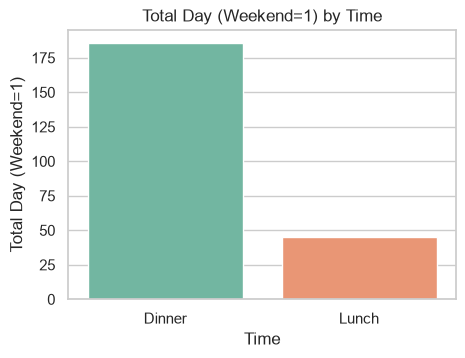

Null hypothesis (H0): There is no significant difference in Day (Weekend=1) between Dinner and Lunch.
Alternative hypothesis (H1): There is a significant difference in Day (Weekend=1) between Dinner and Lunch.

Descriptive summary:
  Dinner                     n= 224  mean=0.8304
  Lunch                      n= 132  mean=0.3409
  Mean difference (Dinner minus Lunch): 0.4894

Shapiro-Wilk Test output (checking normality):
  Dinner Group  W=0.4531  p=< 0.000001
  Lunch Group  W=0.5985  p=< 0.000001
  Data is not perfectly normal (reject H0 for normality)

Levene's Test output (informational):
  Levene's test statistic: 14.0889  p=0.000204
  Variances are significantly different.
  -> Welch's t-test is used regardless (robust to unequal variance).

Welch's Independent T-Test output:
  t-statistic: 10.1033
  p-value:     < 0.000001
  95% CI for mean difference: [0.3940, 0.5849]
  Significant difference between groups (reject H0)

Observation & Analysis:
  The bar chart comparison of total 

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')
from IPython.display import display, Markdown

# =====================================================================
# 1. LOAD DATA & SETUP TARGETS
# =====================================================================
try:
    df_clean = pd.read_csv('Restaurant_Cleaned.csv')
except FileNotFoundError:
    print("Error: 'Restaurant_Cleaned.csv' not found.")

df_clean['Day_Numeric'] = df_clean['Day'].isin(['Sat', 'Sun']).astype(int)
df_clean['Time_Numeric'] = df_clean['Time'].map({'Lunch': 0, 'Dinner': 1})
df_clean['Smoker_Numeric'] = df_clean['Smoker'].map({'No': 0, 'Yes': 1})
df_clean['Gender_Numeric'] = df_clean['Gender'].map({'Female': 0, 'Male': 1})
median_tip = df_clean['Tip'].median()

sns.set_theme(style="whitegrid")

retained_h0_ttest = []
accepted_h1_ttest = []
_sig_analyses_ttest = []  # collects markdown for each significant finding

# =====================================================================
# 2. MASTER FUNCTION: T-TEST
# =====================================================================
def run_beautiful_ttest(target_col, feature_name, g1, g2, label1, label2):
    """
    Welch's independent-samples t-test with full descriptive reporting.
    Always uses Welch's correction (equal_var=False) — Levene's result is
    shown for transparency only, not used to select the test.
    For Tip-as-target: inferential claims are deferred; medians reported.
    """
    print(f"\033[1mComparing {target_col} based on {feature_name} ({label1} vs {label2})\033[0m\n")

    g1_clean = g1.dropna()
    g2_clean = g2.dropna()

    if len(g1_clean) == 0 or len(g2_clean) == 0:
        return  # Skip if data is missing

    # Graph
    df_plot = pd.DataFrame({
        target_col: pd.concat([g1_clean, g2_clean]),
        feature_name: [label1]*len(g1_clean) + [label2]*len(g2_clean)
    })
    plt.figure(figsize=(5, 3.5))
    sns.barplot(x=feature_name, y=target_col, data=df_plot,
                estimator='sum', errorbar=None, palette='Set2')
    plt.title(f"Total {target_col} by {feature_name}", fontsize=12)
    plt.ylabel(f"Total {target_col}")
    plt.xlabel(feature_name)
    plt.show()

    # Hypotheses
    print(f"\033[1mNull hypothesis (H0):\033[0m There is no significant difference in {target_col} between {label1} and {label2}.")
    print(f"\033[1mAlternative hypothesis (H1):\033[0m There is a significant difference in {target_col} between {label1} and {label2}.\n")

    # Descriptive summary
    mean1, mean2 = g1_clean.mean(), g2_clean.mean()
    n1, n2 = len(g1_clean), len(g2_clean)
    mean_diff = mean1 - mean2
    print("\033[1mDescriptive summary:\033[0m")
    print(f"  {label1:25s}  n={n1:4d}  mean={mean1:.4f}")
    print(f"  {label2:25s}  n={n2:4d}  mean={mean2:.4f}")
    print(f"  Mean difference ({label1} minus {label2}): {mean_diff:.4f}\n")

    # Tip-as-target: set aside inferential claims; show median instead
    _is_tip_target = (target_col.split(" ")[0] == "Tip")
    if _is_tip_target:
        med1, med2 = g1_clean.median(), g2_clean.median()
        print("  [NOTE] Tip-based inferential claims are set aside until extreme")
        print("  entries are verified (see audit flags in the cleaning step).")
        print(f"  Interim median -- {label1}: {med1:.2f}  |  {label2}: {med2:.2f}\n")
        print("=" * 75 + "\n")
        retained_h0_ttest.append(
            f"   - {target_col} grouped by {feature_name}: "
            f"[deferred] medians: {label1}={med1:.2f}, {label2}={med2:.2f}"
        )
        return

    # Shapiro-Wilk normality check
    print("\033[1mShapiro-Wilk Test output (checking normality):\033[0m")
    if len(g1_clean) >= 3 and len(g2_clean) >= 3:
        w1, p_s1 = stats.shapiro(g1_clean)
        w2, p_s2 = stats.shapiro(g2_clean)
        print(f"  {label1} Group  W={w1:.4f}  p={'< 0.000001' if p_s1 < 0.000001 else f'{'< 0.000001' if p_s1 < 0.000001 else f'{p_s1:.6f}'}'}")
        print(f"  {label2} Group  W={w2:.4f}  p={'< 0.000001' if p_s2 < 0.000001 else f'{'< 0.000001' if p_s2 < 0.000001 else f'{p_s2:.6f}'}'}")
        if p_s1 < 0.05 or p_s2 < 0.05:
            print("  Data is not perfectly normal (reject H0 for normality)\n")
        else:
            print("  Data is normally distributed (fail to reject H0 for normality)\n")
    else:
        print("  Not enough data to run Shapiro-Wilk.\n")

    # Levene's test (informational only)
    print("\033[1mLevene's Test output (informational):\033[0m")
    stat_lev, p_lev = stats.levene(g1_clean, g2_clean)
    print(f"  Levene's test statistic: {stat_lev:.4f}  p={'< 0.000001' if p_lev < 0.000001 else f'{'< 0.000001' if p_lev < 0.000001 else f'{p_lev:.6f}'}'}")
    if p_lev < 0.05:
        print("  Variances are significantly different.")
    else:
        print("  Variances are not significantly different.")
    print("  -> Welch's t-test is used regardless (robust to unequal variance).\n")

    # Welch's T-Test (always equal_var=False)
    print("\033[1mWelch's Independent T-Test output:\033[0m")
    t_stat, p_ttest = stats.ttest_ind(g1_clean, g2_clean, equal_var=False)
    print(f"  t-statistic: {t_stat:.4f}")
    print(f"  p-value:     {'< 0.000001' if p_ttest < 0.000001 else f'{'< 0.000001' if p_ttest < 0.000001 else f'{p_ttest:.6f}'}'}")

    # 95% CI for the difference in means (Welch-Satterthwaite df)
    import numpy as np
    se1_sq = g1_clean.var(ddof=1) / n1
    se2_sq = g2_clean.var(ddof=1) / n2
    se_diff = np.sqrt(se1_sq + se2_sq)
    df_welch = (se1_sq + se2_sq)**2 / (se1_sq**2/(n1-1) + se2_sq**2/(n2-1))
    t_crit = stats.t.ppf(0.975, df=df_welch)
    ci_lo = mean_diff - t_crit * se_diff
    ci_hi = mean_diff + t_crit * se_diff
    print(f"  95% CI for mean difference: [{ci_lo:.4f}, {ci_hi:.4f}]")

    if p_ttest < 0.05:
        print("  \033[1mSignificant difference between groups (reject H0)\033[0m")
        accepted_h1_ttest.append(
            f"   - {target_col} grouped by {feature_name}: "
            f"Significant (p={'< 0.000001' if p_ttest < 0.000001 else f'{p_ttest:.6f}'}, delta_mean={mean_diff:.4f}, "
            f"95% CI=[{ci_lo:.4f}, {ci_hi:.4f}])"
        )
        # ── Observation & Analysis ─────────────────────────────────────
        _total1    = g1_clean.sum()
        _total2    = g2_clean.sum()
        _grand_tot = _total1 + _total2
        _pct1      = 100 * _total1 / _grand_tot if _grand_tot else 0
        _pct2      = 100 - _pct1
        _higher    = label1 if mean1 >= mean2 else label2
        _lower     = label2 if mean1 >= mean2 else label1
        _h_mean    = max(mean1, mean2)
        _l_mean    = min(mean1, mean2)
        _h_total   = _total1 if mean1 >= mean2 else _total2
        _l_total   = _total2 if mean1 >= mean2 else _total1
        _h_n       = n1 if mean1 >= mean2 else n2
        _l_n       = n2 if mean1 >= mean2 else n1
        _h_pct     = _pct1 if mean1 >= mean2 else _pct2
        _p_disp    = "< 0.000001" if p_ttest < 0.000001 else f"{p_ttest:.6f}"
        _obs_text = (
            f"The bar chart comparison of total **{target_col}** shows that the "
            f"**{_higher}** group accounts for **{_h_total:.2f}** in total {target_col} "
            f"(from {_h_n} records) with an average of **{_h_mean:.2f}** per record, "
            f"while the **{_lower}** group accounts for **{_l_total:.2f}** total "
            f"(from {_l_n} records) with an average of **{_l_mean:.2f}** per record. "
            f"The dataset records **{_grand_tot:.2f}** in combined {target_col} "
            f"({_h_total:.2f} / {_grand_tot:.2f}, **~{_h_pct:.1f}%** from {_higher}). "
            f"After Welch's independent-samples t-test, a statistically significant "
            f"difference was observed (t={t_stat:.4f}, p={_p_disp}), indicating that "
            f"**{feature_name}** exerts a measurable effect on **{target_col}**."
        )
        _mgmt_text = (
            f"Because the **{_higher}** group produces a higher average {target_col} "
            f"(~{_h_mean:.2f} vs ~{_l_mean:.2f} for {_lower}), prioritise operational "
            f"and revenue strategies for the **{_higher}** segment. Investigate what "
            f"distinguishes the {_higher} group and replicate those conditions to raise "
            f"overall {target_col}. For the **{_lower}** group (~{_l_mean:.2f} average), "
            f"consider targeted interventions to close the "
            f"**{_h_mean - _l_mean:.2f}-unit gap** with the better-performing segment."
        )
        _sig_analyses_ttest.append({
            "title": f"{target_col} | grouped by **{feature_name}** ({_higher} vs {_lower})",
            "obs":   _obs_text,
            "mgmt":  _mgmt_text,
            "stats": f"t = {t_stat:.4f} | p = {_p_disp} | Δμ = {mean_diff:.4f} | 95% CI = [{ci_lo:.4f}, {ci_hi:.4f}]",
        })
    else:
        print("  \033[1mFailed to find sufficient evidence of a difference between groups\033[0m")
        retained_h0_ttest.append(
            f"   - {target_col} grouped by {feature_name}: "
            f"No sufficient evidence (p={'< 0.000001' if p_ttest < 0.000001 else f'{p_ttest:.6f}'}, delta_mean={mean_diff:.4f}, "
            f"95% CI=[{ci_lo:.4f}, {ci_hi:.4f}])"
        )

    print("\n" + "=" * 75 + "\n")

# =====================================================================
# 3. RUN THE LOOP OVER ALL COMBINATIONS
# =====================================================================
# Format: (Condition 1, Condition 2, Label 1, Label 2)
features = {
    'Tip': (df_clean['Tip'] > median_tip, df_clean['Tip'] <= median_tip, '> Median Tip', '<= Median Tip'),
    'Partysize': (df_clean['Partysize'] > 2, df_clean['Partysize'] <= 2, '> 2 People', '<= 2 People'),
    'Gender': (df_clean['Gender'] == 'Male', df_clean['Gender'] == 'Female', 'Male', 'Female'),
    'Smoker': (df_clean['Smoker'] == 'Yes', df_clean['Smoker'] == 'No', 'Smoker', 'Non-Smoker'),
    'Time': (df_clean['Time'] == 'Dinner', df_clean['Time'] == 'Lunch', 'Dinner', 'Lunch'),
    'Day': (df_clean['Day'].isin(['Sat', 'Sun']), df_clean['Day'].isin(['Thur', 'Fri']), 'Weekend', 'Weekday')
}

targets = {
    'Amount': df_clean['Amount'],
    'Tip': df_clean['Tip'],
    'Gender (Male=1)': df_clean['Gender_Numeric'],
    'Smoker (Yes=1)': df_clean['Smoker_Numeric'],
    'Time (Dinner=1)': df_clean['Time_Numeric'],
    'Day (Weekend=1)': df_clean['Day_Numeric']
}

for target_name, target_data in targets.items():
    for feature_name, (cond1, cond2, label1, label2) in features.items():
        # Prevent self-comparison (e.g. Tip vs Tip)
        if target_name.split(' ')[0] == feature_name:
            continue
        
        g1 = target_data[cond1]
        g2 = target_data[cond2]
        
        run_beautiful_ttest(target_name, feature_name, g1, g2, label1, label2)
        
# =====================================================================
# 4. COMBINED MARKDOWN ANALYSIS REPORT (significant findings only)
# =====================================================================
if _sig_analyses_ttest:
    _md_ttest = [
        "\n\n---\n",
        "## Part 2 — T-Test Significant Findings\n",
    ]
    for _i, _a in enumerate(_sig_analyses_ttest, 1):
        _md_ttest.append(f"### Finding {_i}: {_a['title']}")
        _md_ttest.append(f"> **Test Statistics:** {_a['stats']}")
        _md_ttest.append(f"\n**Observation & Analysis**\n\n{_a['obs']}")
        _md_ttest.append(f"\n**Managerial Insight**\n\n{_a['mgmt']}")
        _md_ttest.append("\n---")
    _ttest_md_str = "\n\n".join(_md_ttest)
    display(Markdown(_ttest_md_str))
    # Append to analysis.md (created by ANOVA cell)
    try:
        with open('analysis.md', 'a', encoding='utf-8') as _fmd:
            _fmd.write("\n\n" + _ttest_md_str)
        print("[analysis.md] T-test section appended.")
    except Exception as _e:
        print(f"[analysis.md] Could not append T-test section: {_e}")

# =====================================================================
# 5. PRINT FINAL SEGREGATED REPORT
# =====================================================================
print("\n=======================================================")
print(" 📊 FINAL T-TEST HYPOTHESIS SEGREGATION REPORT")
print("=======================================================\n")

print("✅ \033[1mFAILED TO FIND SUFFICIENT EVIDENCE OF A DIFFERENCE (H0 not rejected)\033[0m")
print("-" * 65)
for item in retained_h0_ttest:
    print(item)

print("\n❌ \033[1mACCEPT ALTERNATIVE HYPOTHESIS (H1): Significant Differences Found\033[0m")
print("-" * 65)
for item in accepted_h1_ttest:
    print(item)
print("\n=======================================================")
